In [28]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from IPython.display import display

In [29]:
def calculate_project_score(data, gates, modifiers, weights):
    
    rd= data[0]["rd"]
    sa= data[0]["sa"]
    sc= data[0]["sc"]
    uc= data[0]["uc"]
    ac= data[0]["ac"]
    am= data[0]["am"]
    dp= data[0]["dp"]
    cr= data[0]["cr"]
    vt= data[0]["vt"]
    coh= data[0]["coh"]
    rev= data[0]["rev"]
    fc= data[0]["fc"]
    ref= data[0]["ref"]
    vd= data[0]["vd"]
    
    f_scope= 0.25* rd + 0.2* sa + 0.2* ac + 0.2*dp + 0.15* rev
    c_scope= 0.3* ac+ 0.3*(1-am)+ 0.2*vd + 0.2* ref
    s_stab= max(0, 1 - (math.log(1+sc))/math.log(7)) * (0.5 + 0.5*fc)
    s_s= 0.4* f_scope+ 0.3* c_scope+ 0.3* s_stab
    v_mod= 1- 0.05*(vt-1)*(1-coh)
    k_cli= 0.5 + 0.5* cr
    
    x1 = 0.5*s_s + 0.3*v_mod + 0.2*k_cli
    
    
    
    v= data[1]["v"]
    c= data[1]["c"]
    tb= data[1]["tb"]
    bs= data[1]["bs"]
    pp= data[1]["pp"]
    ps= data[1]["ps"]
    bc= data[1]["bc"]
    crr= data[1]["crr"]
    co= data[1]["co"]
    cm= data[1]["cm"]
    rv= data[1]["rv"]
    cp= data[1]["cp"]
    mg= data[1]["mg"]
    rr= data[1]["rr"]
    dk= data[1]["dk"]
    cp= data[1]["cp"]
    mg= data[1]["mg"]
    rr= data[1]["rr"]
    dk= data[1]["dk"]
    
    mr= max(0, min((v-c)/v, 1))
    v_n= 1+ 1/(math.exp(-0.00003)*(v-150000))
    cpi = pp*tb/(bs+1e-9)
    cpi_n= min(cpi,1.3)/1.3
    h_cash= (2*min(crr,1)*cm)/(min(crr,1)+cm+1e-9)
    o_pen= max(0, math.log(1+co)/math.log(5))
    m_stab= 0.3*min(mg/0.4,1)+0.25*rv+0.25*cp+0.25*rr
    f_pre= 0.3*mr + 0.25*ps + 0.2*bc + 0.15*v_n + 0.1*dk
    f_flight= 0.25*cpi_n + 0.25*h_cash + 0.25*o_pen + 0.25*m_stab
    
    a=min(pp*2,1)
    x2= (1-a)*f_pre+a*(0.4*f_pre+0.6*f_flight)
    
    
    
    ta= data[2]["ta"]
    se= data[2]["se"]
    dm= data[2]["dm"]
    sk= data[2]["sk"]
    kc= data[2]["kc"]
    bs= data[2]["bs"]
    tl= data[2]["tl"]
    ct= data[2]["ct"]
    rl= data[2]["rl"]
    rr= data[2]["rr"]
    ot= data[2]["ot"]
    on= data[2]["on"]
    sr= data[2]["sr"]
    od= data[2]["od"]
    ld= data[2]["ld"]
    bn= data[2]["bn"]
    pp= data[2]["pp"]
    
    ta_prime= min(1,ta)
    s_fill= min(rl/rr,1)
    s_cap= (2*s_fill*ta_prime)/(s_fill+ta_prime+1e-9)
    
    c_comp= 0.25*se + 0.25*dm + 0.2*sk + 0.15*sr + 0.15*ct
    e_conf= min(math.log(1+pp)/math.log(11),1)
    r_res= (1-0.4*kc*(1-bs))*(1-0.5*od)
    
    f_fat= math.exp(-1.5*ot)*max(0,1-on/8)*(1-0.4*bn)
    i_r= 0.5*tl+0.5*ld
    
    x3= 0.25*s_cap + 0.2*c_comp + 0.1*e_conf + 0.15*r_res + 0.15*f_fat + 0.15*i_r
    
    
    
    tr= data[3]["tr"]
    te_est= data[3]["te_est"]
    td= data[3]["td"]
    te= data[3]["te"]
    mc= data[3]["mc"]
    mt= data[3]["mt"]
    md= data[3]["md"]
    ad= data[3]["ad"]
    bf= data[3]["bf"]
    cd= data[3]["cd"]
    vl= data[3]["vl"]
    vl_prime= min(1,vl)
    bl= data[3]["bl"]
    de= data[3]["de"]
    ph= data[3]["ph"]
    pn= data[3]["pn"]
    tz= data[3]["tz"]
    
    tz_prime= max(0,1-abs(12-tz)/12)
    t_p= min(tr/te_est,1)
    spi= mc/(mc+md+1e-9)
    d_sev= math.exp(-0.5*cd)*max(0,1-ad/(bf+1))
    elapsed_ratio= te/td+1e-9
    completion_ratio= mc/mt+1e-9
    
    p_sched= 1/(1+math.exp(-8*(completion_ratio-elapsed_ratio)))
    
    v_health= 0.6*(min(1.2,vl)/1.2)+0.4*bl
    
    d_struct= 0.3*max(0,1-de/8)+0.3*ph+0.2*(1-0.4*pn)+0.2*tz_prime
    
    x4_pre= 0.35*t_p+0.30*d_struct+0.35*v_health
    x4_flight= 0.25*spi+0.2*d_sev+0.2*p_sched+0.15*v_health+0.1*t_p+0.1*d_struct
    
    a= min((te/(td+1e-9))*2,1)
    
    x4= (1-a)*x4_pre+a*x4_flight
    
    
    
    ch= data[4]["ch"]
    cr= data[4]["cr"]
    rt= data[4]["rt"]
    fd= data[4]["fd"]
    dma= data[4]["dma"]
    py= data[4]["py"]
    coc= data[4]["coc"]
    sp= data[4]["sp"]
    ec= data[4]["ec"]
    dc= data[4]["dc"]
    pp= data[4]["pp"]
    ng= data[4]["ng"]
    mf= data[4]["mf"]
    ma= data[4]["ma"]
    es= data[4]["es"]
    e_client= data[4]["e_client"]
    e_ideal= data[4]["e_ideal"]
    
    sz= math.exp(-((math.log(e_client)-math.log(e_ideal))**2)/(2*(1.5**2)))
    
    r_resp= math.exp(-0.04*rt)
    m_qual= ma*min(mf/3,1)
    c_infra= 0.25*min(ec/4,1)+0.25*min(dc/15,1)+0.25*sp+0.25*coc
    q_eng= 0.3*fd + 0.3*pp + 0.2*es + 0.2*dma
    r_client= 0.35*py + 0.25*ch + 0.2*cr + 0.2*sz
    n_damp= max(0,1-0.12*ng)
    
    x5= n_damp*(0.25*r_resp+0.2*q_eng+0.15*m_qual+0.2*c_infra+0.2*r_client)
    
    
    
    ir= data[5]["ir"]
    er= data[5]["er"]
    rc= data[5]["rc"]
    rp= data[5]["rp"]
    fr= data[5]["fr"]
    dr= data[5]["dr"]
    ds= data[5]["ds"]
    ct= data[5]["ct"]
    td= data[5]["td"]
    ag= data[5]["ag"]
    wt= data[5]["wt"]
    
    r_blend= ir**(wt)*er**(1-wt)
    a_bonus= 1+0.15*(ag-0.5)
    r_c= min(rc/(rp+1e-9),1)
    d_eff= ((ds+1)/(dr+1))**0.7
    f_p= fr**0.8
    s_rev= math.exp(-0.3*(td-1))
    
    x6= a_bonus*(0.3*r_blend+0.15*f_p+0.15*d_eff+0.15*s_rev+0.15*ct)
    
    
    
    exp= data[6]["exp"]
    nc= data[6]["nc"]
    is_n= data[6]["is_n"]
    ai= data[6]["ai"]
    dsm= data[6]["dsm"]
    pc= data[6]["pc"]
    re= data[6]["re"]
    tdr= data[6]["tdr"]
    cf= data[6]["cf"]
    pt= data[6]["pt"]
    stf= data[6]["stf"]
    tn= data[6]["tn"]
    qs= data[6]["qs"]
    
    c_burden= 0.25*nc+0.25*min(is_n/6,1)+0.2*ai+0.15*pc+0.15*tn
    c_mit= 0.2*exp+0.15*dsm+0.15*re+0.2*((stf-1)/4)+0.15*pt+0.15*(1-0.3*qs)
    c_net= 1/(1+math.exp(-6*(c_mit-c_burden)))
    e_creative= 0.6*cf+0.4*(1-tdr)
    
    x7= 0.6*c_net+0.4*e_creative
    
    
    
    ri= data[7]["ri"]
    rm= data[7]["rm"]
    rr= data[7]["rr"]
    de= data[7]["de"]
    db= data[7]["db"]
    ci= data[7]["ci"]
    tp= data[7]["tp"]
    sc= data[7]["sc"]
    ctr= data[7]["ctr"]
    ea= data[7]["ea"]
    scr= data[7]["scr"]
    tcr= data[7]["tcr"]
    fnr= data[7]["fnr"]
    lgr= data[7]["lgr"]
    rpr= data[7]["rpr"]
    tnr= data[7]["tnr"]
    
    r_prep= (rm+1)/(ri+1)
    r_mat= 1/(1+math.exp(5*((rr/(ri+1))-0.3)))
    d_health= (1-db/(de+1))*((ci+tp)/2)
    c_sec= 0.6*sc+0.4*ctr
    ea_prime= math.exp(-0.4*ea)
    r_cat= 1-(0.2*scr**2+0.2*tcr**2+0.15*fnr**2+0.1*lgr**2+0.1*rpr**2+0.15*(db/(de+1))**2+0.1*tnr**2)**(1/2)
    
    x8= ea_prime*(0.2*r_prep+0.2*r_mat+0.15*d_health+0.15*c_sec+0.3*r_cat)
    
    
    
    cs= data[8]["cs"]
    nps= data[8]["nps"]
    ts= data[8]["ts"]
    ef= data[8]["ef"]
    ce= data[8]["ce"]
    pr= data[8]["pr"]
    ref= data[8]["ref"]
    tc= data[8]["tc"]
    ip= data[8]["ip"]
    cl= data[8]["cl"]
    
    nps_n= nps/10
    s_client= 0.2*cs+0.15*nps_n+0.2*ef+0.15*pr+0.1*ref+0.1*tc+0.1*cl
    s_internal= 0.5*ts+0.5*ip
    
    p_comp= max(0,1-math.log(1+ce)/math.log(6))
    
    x9= p_comp*(0.65*s_client+0.35*s_internal)
    
    
    
    sv= data[9]["sv"]
    bp= data[9]["bp"]
    csp= data[9]["csp"]
    in_n= data[9]["in_n"]
    lp= data[9]["lp"]
    mkt= data[9]["mkt"]
    pa= data[9]["pa"]
    vta= data[9]["vta"]
    n_new= data[9]["n_new"]
    
    v_market= 0.25*sv+0.25*bp+0.25*csp+0.25*mkt
    lrn= 1-math.exp(-0.5*n_new)
    v_know= 0.35*lp+0.35*in_n+0.3*lrn
    v_port= 0.5*vta+0.5*pa
    
    x10= 0.45*v_market+0.30*v_know+0.25*v_port
    
    
    
    rp= data[10]["rp"]
    ut= data[10]["ut"]
    esv= data[10]["esv"]
    rf= data[10]["rf"]
    phn= data[10]["phn"]
    rt= data[10]["rt"]
    cr= data[10]["cr"]
    exp= data[10]["exp"]
    ltv= data[10]["ltv"]
    fv= data[10]["fv"]
    
    ph_n= min(phn/5,1)
    cr_n= min(cr/4,1)
    ltv_n= 1/(1+math.exp(-0.8*(ltv/(fv+1e-9)-3)))
    v_growth= 0.2*rp+0.15*ut+0.15*esv+0.15*rf+0.1*ph_n+0.1*rt+0.05*cr_n+0.1*exp
    
    x11= 0.55*v_growth+0.45*ltv_n
    
    
    
    nc= data[11]["nc"]
    wh= data[11]["wh"]
    usp= data[11]["usp"]
    pours= data[11]["pours"]
    pmkt= data[11]["pmkt"]
    rla= data[11]["rla"]
    s= data[11]["s"]
    rpq= data[11]["rpq"]
    
    n_comp= max(0,1-nc/8)
    pr_comp= math.exp(-2*(max(0,(pours-pmkt)/(pmkt+1e-9)))**2)
    
    x12= 0.2*n_comp+0.2*wh+0.2*usp+0.15*pr_comp+0.15*rla+0.1*rpq
    
    
    
    mt= data[12]["mt"]
    rt= data[12]["rt"]
    sth= data[12]["sth"]
    doc= data[12]["doc"]
    fb= data[12]["fb"]
    pro= data[12]["pro"]
    ng= data[12]["ng"]
    
    mt_n= min(mt/5,1)
    rt_s= math.exp(-0.05*rt)
    st_n= min(sth/4,1)
    doc_n= min(doc/6,1)
    ng_n= max(0, 1-0.15*ng)
    
    x13= ng_n*(0.2*mt_n+0.2*rt_s+0.15*st_n+0.15*doc_n+0.2*fb+0.15*pro)
    
    
    
    mt= data[12]["mt"]
    rt= data[12]["rt"]
    sth= data[12]["sth"]
    doc= data[12]["doc"]
    fb= data[12]["fb"]
    pro= data[12]["pro"]
    ng= data[12]["ng"]
    
    mt_n= min(mt/5,1)
    rt_s= math.exp(-0.05*rt)
    st_n= min(sth/4,1)
    doc_n= min(doc/6,1)
    ng_n= max(0, 1-0.15*ng)
    
    x13= ng_n*(0.2*mt_n+0.2*rt_s+0.15*st_n+0.15*doc_n+0.2*fb+0.15*pro)
    
    
    
    qs= data[13]["qs"]
    ac= data[13]["ac"]
    wm= data[13]["wm"]
    pq= data[13]["pq"]
    
    x14= 0.5*qs+0.1*ac+0.2*wm+0.2*pq
    
    
    
    G=1
    
    for i in range(len(gates)):
      if gates[i]=='t':
        G=0
    
    M=1
    
    for i in range(len(modifiers)):
      M=M*modifiers[i]
    
    
    x=[x1, x2, x3, x4, x5, x6, x7, x8, x9, x10, x11, x12, x13, x14]
    
    wx=0
    
    for i in range(len(weights)):
        wx=wx+x[i]*weights[i]
    
    Score = 100 * G * M * wx
    
    return {
        "score":       Score,
            "gate_result": G,
            "modifier":    round(M, 4),
            "x1":   round(x1,  4),
            "x2":   round(x2,  4),
            "x3":   round(x3,  4),
            "x4":   round(x4,  4),
            "x5":   round(x5,  4),
            "x6":   round(x6,  4),
            "x7":   round(x7,  4),
            "x8":   round(x8,  4),
            "x9":   round(x9,  4),
            "x10":  round(x10, 4),
            "x11":  round(x11, 4),
            "x12":  round(x12, 4),
            "x13":  round(x13, 4),
            "x14":  round(x14, 4)
    }
    


In [30]:
DEFAULT_WEIGHTS = [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]

test_cases=[
    {
        "case_id": "TC01",
        "label": "Near-Perfect Enterprise Project",
        "summary": "Repeat client, fully documented scope, strong margins, dedicated team, all gates pass. Should score 85+.",
        "data": [
            {
                "rd": 0.95, "sa": 1.0, "sc": 0, "uc": 0.95, "ac": 0.95,
                "am": 0.05, "dp": 0.95, "cr": 0.9, "vt": 2, "coh": 0.95,
                "rev": 1.0, "fc": 1.0, "ref": 0.9, "vd": 0.9
            },
            {
                "v": 5000000, "c": 2800000, "tb": 3200000, "bs": 800000,
                "pp": 0.3, "ps": 1.0, "bc": 1.0, "crr": 1.0, "co": 0,
                "cm": 1.0, "rv": 1.0, "cp": 1.0, "mg": 0.44, "rr": 0.8, "dk": 1.0
            },
            {
                "ta": 1.0, "se": 0.9, "dm": 0.95, "sk": 0.95, "kc": 0.1,
                "bs": 0.8, "tl": 1.0, "ct": 0.8, "rl": 8, "rr": 8,
                "ot": 0.05, "on": 1, "sr": 1.0, "od": 0.0, "ld": 1.0,
                "bn": 0.1, "pp": 6
            },
            {
                "tr": 150, "te_est": 140, "td": 150, "te": 45, "mc": 4,
                "mt": 10, "md": 0, "ad": 0.0, "bf": 20, "cd": 0,
                "vl": 1.0, "bl": 0.95, "de": 1, "ph": 1.0, "pn": 0.0,
                "tz": 0.0
            },
            {
                "ch": 1.0, "cr": 0.9, "rt": 2.0, "fd": 0.9, "dma": 1.0,
                "py": 1.0, "coc": 0.95, "sp": 1.0, "ec": 3, "dc": 20,
                "pp": 0.85, "ng": 0, "mf": 3, "ma": 0.95, "es": 0.9,
                "e_client": 200, "e_ideal": 200
            },
            {
                "ir": 0.95, "er": 0.9, "rc": 4, "rp": 8, "fr": 0.85,
                "dr": 5, "ds": 5, "ct": 0.95, "td": 1.5, "ag": 0.9, "wt": 0.5
            },
            {
                "exp": 0.95, "nc": 0.1, "is_n": 2, "ai": 0.0, "dsm": 0.9,
                "pc": 0.2, "re": 0.8, "tdr": 0.05, "cf": 0.9, "pt": 0.9,
                "stf": 5, "tn": 0.1, "qs": 0.3
            },
            {
                "ri": 6, "rm": 6, "rr": 0, "de": 3, "db": 0,
                "ci": 0.95, "tp": 0.9, "sc": 0.95, "ctr": 0.9, "ea": 0,
                "scr": 0.1, "tcr": 0.1, "fnr": 0.05, "lgr": 0.05,
                "rpr": 0.05, "tnr": 0.05
            },
            {
                "cs": 0.95, "nps": 9.0, "ts": 0.9, "ef": 0.9, "ce": 0,
                "pr": 0.9, "ref": 0.9, "tc": 0.9, "ip": 0.95, "cl": 0.9
            },
            {
                "sv": 0.8, "bp": 0.9, "csp": 1.0, "in_n": 0.5,
                "lp": 0.7, "mkt": 0.8, "pa": 0.8, "vta": 0.9, "n_new": 2
            },
            {
                "rp": 0.9, "ut": 0.85, "esv": 0.75, "rf": 0.85, "phn": 3,
                "rt": 0.8, "cr": 4, "exp": 0.8,
                "ltv": 15000000, "fv": 5000000
            },
            {
                "nc": 0, "wh": 0.9, "usp": 0.9, "pours": 5000000,
                "pmkt": 5200000, "rla": 0.9, "s": 1, "rpq": 0.95
            },
            {
                "mt": 8, "rt": 2, "sth": 4, "doc": 6, "fb": 0.9,
                "pro": 0.9, "ng": 0
            },
            {
                "qs": 0.9, "ac": 0.95, "wm": 1.0, "pq": 0.9
            }
        ],
        "gates": ["f","f","f","f","f","f","f","f","f","f","f"],
        "modifiers": [1,1,1,1,1,1,1],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    },

    {
        "case_id": "TC02",
        "label": "High-Risk Startup Client",
        "summary": "New startup client, vague scope, tight budget, unproven payment history, bleeding-edge AI project. High novelty, low stability.",
        "data": [
            {
                "rd": 0.3, "sa": 0.25, "sc": 5, "uc": 0.35, "ac": 0.3,
                "am": 0.6, "dp": 0.4, "cr": 0.4, "vt": 2, "coh": 0.5,
                "rev": 0.0, "fc": 0.2, "ref": 0.2, "vd": 0.25
            },
            {
                "v": 800000, "c": 700000, "tb": 750000, "bs": 100000,
                "pp": 0.1, "ps": 0.4, "bc": 0.25, "crr": 0.6, "co": 2,
                "cm": 0.5, "rv": 0.4, "cp": 0.2, "mg": 0.12, "rr": 0.3, "dk": 0.7
            },
            {
                "ta": 0.6, "se": 0.5, "dm": 0.4, "sk": 0.55, "kc": 0.7,
                "bs": 0.2, "tl": 0.7, "ct": 0.3, "rl": 3, "rr": 5,
                "ot": 0.4, "on": 4, "sr": 0.4, "od": 0.4, "ld": 0.5,
                "bn": 0.5, "pp": 1
            },
            {
                "tr": 45, "te_est": 90, "td": 60, "te": 10, "mc": 0,
                "mt": 8, "md": 1, "ad": 5.0, "bf": 5, "cd": 1,
                "vl": 0.5, "bl": 0.4, "de": 5, "ph": 0.0, "pn": 0.0,
                "tz": 8.0
            },
            {
                "ch": 0.0, "cr": 0.3, "rt": 24.0, "fd": 0.3, "dma": 0.5,
                "py": 0.5, "coc": 0.4, "sp": 0.5, "ec": 2, "dc": 3,
                "pp": 0.3, "ng": 3, "mf": 1, "ma": 0.6, "es": 0.3,
                "e_client": 15, "e_ideal": 200
            },
            {
                "ir": 0.6, "er": 0.5, "rc": 1, "rp": 4, "fr": 0.3,
                "dr": 12, "ds": 6, "ct": 0.5, "td": 4.0, "ag": 0.4, "wt": 0.5
            },
            {
                "exp": 0.4, "nc": 0.8, "is_n": 6, "ai": 0.9, "dsm": 0.2,
                "pc": 0.6, "re": 0.2, "tdr": 0.5, "cf": 0.6, "pt": 0.2,
                "stf": 2, "tn": 0.8, "qs": 0.7
            },
            {
                "ri": 10, "rm": 4, "rr": 4, "de": 7, "db": 3,
                "ci": 0.4, "tp": 0.5, "sc": 0.5, "ctr": 0.4, "ea": 2,
                "scr": 0.6, "tcr": 0.7, "fnr": 0.5, "lgr": 0.2,
                "rpr": 0.3, "tnr": 0.5
            },
            {
                "cs": 0.5, "nps": 4.0, "ts": 0.5, "ef": 0.4, "ce": 2,
                "pr": 0.4, "ref": 0.3, "tc": 0.4, "ip": 0.4, "cl": 0.5
            },
            {
                "sv": 0.6, "bp": 0.3, "csp": 0.5, "in_n": 0.8,
                "lp": 0.7, "mkt": 0.5, "pa": 0.6, "vta": 0.7, "n_new": 5
            },
            {
                "rp": 0.3, "ut": 0.4, "esv": 0.3, "rf": 0.2, "phn": 0,
                "rt": 0.2, "cr": 1, "exp": 0.3,
                "ltv": 1200000, "fv": 800000
            },
            {
                "nc": 5, "wh": 0.4, "usp": 0.5, "pours": 800000,
                "pmkt": 600000, "rla": 0.2, "s": 0, "rpq": 0.5
            },
            {
                "mt": 2, "rt": 18, "sth": 1, "doc": 1, "fb": 0.4,
                "pro": 0.3, "ng": 3
            },
            {
                "qs": 0.3, "ac": 0.5, "wm": 0.4, "pq": 0.3
            }
        ],
        "gates": ["f","f","f","f","f","f","f","f","f","f","f"],
        "modifiers": [0.7, 0.85, 0.85, 0.7, 0.7, 0.9, 0.85],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    },

    {
        "case_id": "TC03",
        "label": "Gate Failure — No Contract",
        "summary": "Promising project on paper but no signed contract or SOW. Gate G1 fails, score must be zero.",
        "data": [
            {
                "rd": 0.8, "sa": 0.5, "sc": 1, "uc": 0.75, "ac": 0.85,
                "am": 0.2, "dp": 0.8, "cr": 0.8, "vt": 1, "coh": 1.0,
                "rev": 0.5, "fc": 0.7, "ref": 0.6, "vd": 0.7
            },
            {
                "v": 1500000, "c": 900000, "tb": 1000000, "bs": 0,
                "pp": 0.0, "ps": 0.2, "bc": 0.25, "crr": 0.0, "co": 0,
                "cm": 0.0, "rv": 0.5, "cp": 0.0, "mg": 0.4, "rr": 0.5, "dk": 1.0
            },
            {
                "ta": 0.85, "se": 0.8, "dm": 0.8, "sk": 0.85, "kc": 0.2,
                "bs": 0.7, "tl": 0.9, "ct": 0.7, "rl": 4, "rr": 4,
                "ot": 0.1, "on": 2, "sr": 0.8, "od": 0.1, "ld": 1.0,
                "bn": 0.15, "pp": 5
            },
            {
                "tr": 60, "te_est": 55, "td": 60, "te": 0, "mc": 0,
                "mt": 6, "md": 0, "ad": 0.0, "bf": 10, "cd": 0,
                "vl": 0.85, "bl": 0.8, "de": 2, "ph": 1.0, "pn": 0.0,
                "tz": 0.0
            },
            {
                "ch": 0.0, "cr": 0.7, "rt": 4.0, "fd": 0.75, "dma": 0.8,
                "py": 0.5, "coc": 0.8, "sp": 0.8, "ec": 2, "dc": 5,
                "pp": 0.6, "ng": 0, "mf": 2, "ma": 0.85, "es": 0.7,
                "e_client": 180, "e_ideal": 200
            },
            {
                "ir": 0.0, "er": 0.0, "rc": 0, "rp": 4, "fr": 0.0,
                "dr": 0, "ds": 0, "ct": 0.8, "td": 2.0, "ag": 0.5, "wt": 0.5
            },
            {
                "exp": 0.85, "nc": 0.15, "is_n": 2, "ai": 0.0, "dsm": 0.8,
                "pc": 0.3, "re": 0.7, "tdr": 0.1, "cf": 0.85, "pt": 0.5,
                "stf": 4, "tn": 0.15, "qs": 0.3
            },
            {
                "ri": 5, "rm": 4, "rr": 0, "de": 2, "db": 0,
                "ci": 0.7, "tp": 0.8, "sc": 0.85, "ctr": 0.8, "ea": 0,
                "scr": 0.2, "tcr": 0.15, "fnr": 0.1, "lgr": 0.05,
                "rpr": 0.1, "tnr": 0.1
            },
            {
                "cs": 0.7, "nps": 7.0, "ts": 0.8, "ef": 0.7, "ce": 0,
                "pr": 0.7, "ref": 0.6, "tc": 0.7, "ip": 0.75, "cl": 0.8
            },
            {
                "sv": 0.5, "bp": 0.6, "csp": 0.5, "in_n": 0.4,
                "lp": 0.5, "mkt": 0.5, "pa": 0.7, "vta": 0.75, "n_new": 1
            },
            {
                "rp": 0.5, "ut": 0.6, "esv": 0.5, "rf": 0.5, "phn": 1,
                "rt": 0.4, "cr": 2, "exp": 0.5,
                "ltv": 3000000, "fv": 1500000
            },
            {
                "nc": 2, "wh": 0.7, "usp": 0.7, "pours": 1500000,
                "pmkt": 1600000, "rla": 0.3, "s": 0, "rpq": 0.75
            },
            {
                "mt": 4, "rt": 5, "sth": 2, "doc": 3, "fb": 0.7,
                "pro": 0.6, "ng": 0
            },
            {
                "qs": 0.5, "ac": 0.7, "wm": 1.0, "pq": 0.65
            }
        ],
        "gates": ["t","f","f","f","f","f","f","f","f","f","f"],
        "modifiers": [1,1,1,1,1,1,1],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    },

    {
        "case_id": "TC04",
        "label": "Government Contract — Bureaucratic but Stable",
        "summary": "Large government project with slow decision-making, heavy compliance, excellent payment reliability, long timeline, low creativity.",
        "data": [
            {
                "rd": 0.9, "sa": 1.0, "sc": 1, "uc": 0.7, "ac": 0.85,
                "am": 0.2, "dp": 0.9, "cr": 0.3, "vt": 1, "coh": 1.0,
                "rev": 1.0, "fc": 0.9, "ref": 0.8, "vd": 0.8
            },
            {
                "v": 8000000, "c": 5500000, "tb": 6000000, "bs": 1500000,
                "pp": 0.2, "ps": 1.0, "bc": 1.0, "crr": 0.95, "co": 0,
                "cm": 0.95, "rv": 1.0, "cp": 0.9, "mg": 0.31, "rr": 0.7, "dk": 1.0
            },
            {
                "ta": 0.85, "se": 0.8, "dm": 0.7, "sk": 0.9, "kc": 0.15,
                "bs": 0.7, "tl": 0.85, "ct": 0.6, "rl": 10, "rr": 10,
                "ot": 0.15, "on": 1, "sr": 0.9, "od": 0.05, "ld": 1.0,
                "bn": 0.2, "pp": 3
            },
            {
                "tr": 365, "te_est": 300, "td": 365, "te": 90, "mc": 3,
                "mt": 15, "md": 0, "ad": 0.0, "bf": 45, "cd": 0,
                "vl": 0.8, "bl": 0.9, "de": 4, "ph": 1.0, "pn": 1.0,
                "tz": 0.0
            },
            {
                "ch": 0.0, "cr": 0.9, "rt": 48.0, "fd": 0.5, "dma": 0.0,
                "py": 1.0, "coc": 0.6, "sp": 0.5, "ec": 2, "dc": 25,
                "pp": 0.3, "ng": 0, "mf": 1, "ma": 0.8, "es": 0.4,
                "e_client": 5000, "e_ideal": 200
            },
            {
                "ir": 0.85, "er": 0.7, "rc": 3, "rp": 10, "fr": 0.5,
                "dr": 15, "ds": 12, "ct": 0.95, "td": 5.0, "ag": 0.6, "wt": 0.6
            },
            {
                "exp": 0.75, "nc": 0.1, "is_n": 3, "ai": 0.0, "dsm": 0.6,
                "pc": 0.2, "re": 0.5, "tdr": 0.15, "cf": 0.3, "pt": 0.8,
                "stf": 4, "tn": 0.0, "qs": 1.0
            },
            {
                "ri": 12, "rm": 10, "rr": 1, "de": 6, "db": 1,
                "ci": 0.5, "tp": 0.85, "sc": 0.95, "ctr": 0.6, "ea": 0,
                "scr": 0.15, "tcr": 0.1, "fnr": 0.05, "lgr": 0.3,
                "rpr": 0.15, "tnr": 0.1
            },
            {
                "cs": 0.7, "nps": 7.0, "ts": 0.65, "ef": 0.75, "ce": 0,
                "pr": 0.6, "ref": 0.5, "tc": 0.5, "ip": 0.8, "cl": 0.5
            },
            {
                "sv": 0.9, "bp": 0.95, "csp": 0.0, "in_n": 0.3,
                "lp": 0.4, "mkt": 0.9, "pa": 0.6, "vta": 0.7, "n_new": 1
            },
            {
                "rp": 0.7, "ut": 0.5, "esv": 0.8, "rf": 0.4, "phn": 2,
                "rt": 0.6, "cr": 2, "exp": 0.6,
                "ltv": 20000000, "fv": 8000000
            },
            {
                "nc": 6, "wh": 0.5, "usp": 0.6, "pours": 8000000,
                "pmkt": 8500000, "rla": 0.4, "s": 0, "rpq": 0.85
            },
            {
                "mt": 5, "rt": 12, "sth": 5, "doc": 6, "fb": 0.6,
                "pro": 0.3, "ng": 0
            },
            {
                "qs": 1.0, "ac": 0.95, "wm": 1.0, "pq": 0.9
            }
        ],
        "gates": ["f","f","f","f","f","f","f","f","f","f","f"],
        "modifiers": [0.9, 1, 0.7, 1, 0.7, 0.95, 0.85],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    },

    {
        "case_id": "TC05",
        "label": "Small Branding Project — Quick Win",
        "summary": "Single-vertical branding project, small budget, fast turnaround, repeat client, minimal complexity.",
        "data": [
            {
                "rd": 0.7, "sa": 0.75, "sc": 0, "uc": 0.7, "ac": 0.7,
                "am": 0.2, "dp": 0.75, "cr": 0.85, "vt": 1, "coh": 1.0,
                "rev": 0.5, "fc": 0.7, "ref": 0.8, "vd": 0.65
            },
            {
                "v": 200000, "c": 120000, "tb": 150000, "bs": 60000,
                "pp": 0.5, "ps": 0.8, "bc": 0.75, "crr": 1.0, "co": 0,
                "cm": 1.0, "rv": 0.8, "cp": 0.5, "mg": 0.4, "rr": 0.4, "dk": 1.0
            },
            {
                "ta": 1.0, "se": 0.7, "dm": 0.9, "sk": 1.0, "kc": 0.5,
                "bs": 0.4, "tl": 1.0, "ct": 0.5, "rl": 2, "rr": 2,
                "ot": 0.1, "on": 3, "sr": 0.7, "od": 0.0, "ld": 0.5,
                "bn": 0.2, "pp": 8
            },
            {
                "tr": 21, "te_est": 20, "td": 21, "te": 10, "mc": 2,
                "mt": 4, "md": 0, "ad": 0.0, "bf": 3, "cd": 0,
                "vl": 1.0, "bl": 0.9, "de": 1, "ph": 0.5, "pn": 0.0,
                "tz": 0.0
            },
            {
                "ch": 1.0, "cr": 0.7, "rt": 3.0, "fd": 0.85, "dma": 1.0,
                "py": 1.0, "coc": 0.9, "sp": 1.0, "ec": 2, "dc": 8,
                "pp": 0.8, "ng": 0, "mf": 2, "ma": 1.0, "es": 0.85,
                "e_client": 50, "e_ideal": 200
            },
            {
                "ir": 0.8, "er": 0.85, "rc": 2, "rp": 3, "fr": 0.8,
                "dr": 3, "ds": 3, "ct": 0.8, "td": 1.0, "ag": 0.85, "wt": 0.4
            },
            {
                "exp": 0.95, "nc": 0.05, "is_n": 0, "ai": 0.0, "dsm": 1.0,
                "pc": 0.1, "re": 0.9, "tdr": 0.0, "cf": 0.9, "pt": 1.0,
                "stf": 5, "tn": 0.0, "qs": 0.2
            },
            {
                "ri": 3, "rm": 3, "rr": 0, "de": 1, "db": 0,
                "ci": 0.9, "tp": 0.9, "sc": 0.8, "ctr": 0.9, "ea": 0,
                "scr": 0.1, "tcr": 0.05, "fnr": 0.05, "lgr": 0.0,
                "rpr": 0.05, "tnr": 0.1
            },
            {
                "cs": 0.9, "nps": 8.5, "ts": 0.85, "ef": 0.85, "ce": 0,
                "pr": 0.85, "ref": 0.8, "tc": 0.85, "ip": 0.8, "cl": 0.9
            },
            {
                "sv": 0.2, "bp": 0.3, "csp": 0.5, "in_n": 0.1,
                "lp": 0.2, "mkt": 0.2, "pa": 0.5, "vta": 0.8, "n_new": 0
            },
            {
                "rp": 0.85, "ut": 0.7, "esv": 0.4, "rf": 0.7, "phn": 1,
                "rt": 0.5, "cr": 2, "exp": 0.5,
                "ltv": 800000, "fv": 200000
            },
            {
                "nc": 1, "wh": 0.8, "usp": 0.6, "pours": 200000,
                "pmkt": 220000, "rla": 0.9, "s": 1, "rpq": 0.7
            },
            {
                "mt": 4, "rt": 3, "sth": 1, "doc": 4, "fb": 0.85,
                "pro": 0.8, "ng": 0
            },
            {
                "qs": 0.85, "ac": 0.9, "wm": 1.0, "pq": 0.75
            }
        ],
        "gates": ["f","f","f","f","f","f","f","f","f","f","f"],
        "modifiers": [1,1,1,1,1,0.95,1],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    },

    {
        "case_id": "TC06",
        "label": "Nightmare Client — Scope Creep and Ghosting",
        "summary": "Client with massive scope creep, poor communication, frequent ghosting, contradictory feedback, low payment compliance.",
        "data": [
            {
                "rd": 0.4, "sa": 0.25, "sc": 8, "uc": 0.3, "ac": 0.25,
                "am": 0.7, "dp": 0.35, "cr": 0.2, "vt": 3, "coh": 0.3,
                "rev": 0.0, "fc": 0.1, "ref": 0.1, "vd": 0.2
            },
            {
                "v": 1200000, "c": 1000000, "tb": 1100000, "bs": 700000,
                "pp": 0.4, "ps": 0.4, "bc": 0.5, "crr": 0.5, "co": 4,
                "cm": 0.4, "rv": 0.3, "cp": 0.1, "mg": 0.1, "rr": 0.2, "dk": 1.0
            },
            {
                "ta": 0.7, "se": 0.6, "dm": 0.65, "sk": 0.7, "kc": 0.4,
                "bs": 0.3, "tl": 0.8, "ct": 0.4, "rl": 4, "rr": 5,
                "ot": 0.5, "on": 3, "sr": 0.5, "od": 0.2, "ld": 0.5,
                "bn": 0.6, "pp": 2
            },
            {
                "tr": 60, "te_est": 90, "td": 75, "te": 50, "mc": 3,
                "mt": 8, "md": 4, "ad": 7.0, "bf": 2, "cd": 2,
                "vl": 0.55, "bl": 0.4, "de": 5, "ph": 0.0, "pn": 0.5,
                "tz": 3.0
            },
            {
                "ch": 0.5, "cr": 0.4, "rt": 48.0, "fd": 0.2, "dma": 0.0,
                "py": 0.3, "coc": 0.3, "sp": 0.3, "ec": 5, "dc": 4,
                "pp": 0.15, "ng": 5, "mf": 1, "ma": 0.4, "es": 0.2,
                "e_client": 30, "e_ideal": 200
            },
            {
                "ir": 0.6, "er": 0.35, "rc": 3, "rp": 5, "fr": 0.2,
                "dr": 20, "ds": 10, "ct": 0.5, "td": 5.0, "ag": 0.3, "wt": 0.5
            },
            {
                "exp": 0.6, "nc": 0.5, "is_n": 4, "ai": 0.3, "dsm": 0.3,
                "pc": 0.5, "re": 0.3, "tdr": 0.4, "cf": 0.3, "pt": 0.3,
                "stf": 3, "tn": 0.4, "qs": 0.6
            },
            {
                "ri": 10, "rm": 3, "rr": 5, "de": 6, "db": 3,
                "ci": 0.3, "tp": 0.6, "sc": 0.7, "ctr": 0.5, "ea": 3,
                "scr": 0.7, "tcr": 0.4, "fnr": 0.4, "lgr": 0.15,
                "rpr": 0.4, "tnr": 0.4
            },
            {
                "cs": 0.35, "nps": 3.0, "ts": 0.4, "ef": 0.3, "ce": 4,
                "pr": 0.2, "ref": 0.1, "tc": 0.3, "ip": 0.3, "cl": 0.3
            },
            {
                "sv": 0.2, "bp": 0.2, "csp": 0.0, "in_n": 0.2,
                "lp": 0.2, "mkt": 0.1, "pa": 0.4, "vta": 0.4, "n_new": 0
            },
            {
                "rp": 0.1, "ut": 0.15, "esv": 0.1, "rf": 0.05, "phn": 0,
                "rt": 0.1, "cr": 0, "exp": 0.1,
                "ltv": 1200000, "fv": 1200000
            },
            {
                "nc": 2, "wh": 0.5, "usp": 0.4, "pours": 1200000,
                "pmkt": 1000000, "rla": 0.3, "s": 0, "rpq": 0.5
            },
            {
                "mt": 3, "rt": 24, "sth": 1, "doc": 1, "fb": 0.3,
                "pro": 0.2, "ng": 5
            },
            {
                "qs": 0.2, "ac": 0.4, "wm": 0.4, "pq": 0.3
            }
        ],
        "gates": ["f","f","f","f","f","f","f","f","f","f","f"],
        "modifiers": [0.7, 1, 1, 1, 0.85, 0.85, 1],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    },

    {
        "case_id": "TC07",
        "label": "Pre-Sales Stage — Cold Inbound RFP",
        "summary": "Project at proposal stage, no work started, competitive bid, moderate information available. Tests pre-sales weighting.",
        "data": [
            {
                "rd": 0.6, "sa": 0.5, "sc": 0, "uc": 0.55, "ac": 0.5,
                "am": 0.4, "dp": 0.6, "cr": 0.5, "vt": 2, "coh": 0.6,
                "rev": 0.5, "fc": 0.5, "ref": 0.4, "vd": 0.45
            },
            {
                "v": 3000000, "c": 2000000, "tb": 2200000, "bs": 0,
                "pp": 0.0, "ps": 0.6, "bc": 0.5, "crr": 0.0, "co": 0,
                "cm": 0.0, "rv": 0.6, "cp": 0.0, "mg": 0.33, "rr": 0.4, "dk": 1.0
            },
            {
                "ta": 0.8, "se": 0.75, "dm": 0.7, "sk": 0.8, "kc": 0.25,
                "bs": 0.5, "tl": 0.85, "ct": 0.5, "rl": 0, "rr": 6,
                "ot": 0.15, "on": 2, "sr": 0.7, "od": 0.1, "ld": 1.0,
                "bn": 0.2, "pp": 3
            },
            {
                "tr": 120, "te_est": 110, "td": 120, "te": 0, "mc": 0,
                "mt": 10, "md": 0, "ad": 0.0, "bf": 15, "cd": 0,
                "vl": 0.8, "bl": 0.7, "de": 3, "ph": 0.5, "pn": 0.5,
                "tz": 2.0
            },
            {
                "ch": 0.0, "cr": 0.6, "rt": 8.0, "fd": 0.6, "dma": 0.5,
                "py": 0.5, "coc": 0.65, "sp": 0.7, "ec": 2, "dc": 5,
                "pp": 0.5, "ng": 0, "mf": 1, "ma": 0.8, "es": 0.5,
                "e_client": 300, "e_ideal": 200
            },
            {
                "ir": 0.0, "er": 0.0, "rc": 0, "rp": 6, "fr": 0.0,
                "dr": 0, "ds": 0, "ct": 0.7, "td": 2.0, "ag": 0.5, "wt": 0.5
            },
            {
                "exp": 0.7, "nc": 0.3, "is_n": 3, "ai": 0.3, "dsm": 0.6,
                "pc": 0.3, "re": 0.5, "tdr": 0.15, "cf": 0.7, "pt": 0.4,
                "stf": 3, "tn": 0.3, "qs": 0.5
            },
            {
                "ri": 5, "rm": 3, "rr": 0, "de": 4, "db": 0,
                "ci": 0.6, "tp": 0.7, "sc": 0.8, "ctr": 0.7, "ea": 0,
                "scr": 0.3, "tcr": 0.25, "fnr": 0.2, "lgr": 0.1,
                "rpr": 0.15, "tnr": 0.15
            },
            {
                "cs": 0.6, "nps": 6.0, "ts": 0.7, "ef": 0.6, "ce": 0,
                "pr": 0.6, "ref": 0.5, "tc": 0.6, "ip": 0.65, "cl": 0.65
            },
            {
                "sv": 0.6, "bp": 0.7, "csp": 0.5, "in_n": 0.5,
                "lp": 0.5, "mkt": 0.6, "pa": 0.65, "vta": 0.7, "n_new": 2
            },
            {
                "rp": 0.4, "ut": 0.5, "esv": 0.5, "rf": 0.4, "phn": 1,
                "rt": 0.3, "cr": 2, "exp": 0.4,
                "ltv": 6000000, "fv": 3000000
            },
            {
                "nc": 4, "wh": 0.55, "usp": 0.65, "pours": 3000000,
                "pmkt": 3200000, "rla": 0.2, "s": 0, "rpq": 0.7
            },
            {
                "mt": 3, "rt": 8, "sth": 2, "doc": 3, "fb": 0.65,
                "pro": 0.5, "ng": 0
            },
            {
                "qs": 1.0, "ac": 0.8, "wm": 1.0, "pq": 0.7
            }
        ],
        "gates": ["f","f","f","f","f","f","f","f","f","f","f"],
        "modifiers": [0.75, 1, 1, 1, 1, 0.95, 0.85],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    },

    {
        "case_id": "TC08",
        "label": "Multi-Vertical Mega Project",
        "summary": "6-vertical project spanning design, dev, marketing, AI, PTaaS, and branding. High value but extreme coordination complexity.",
        "data": [
            {
                "rd": 0.75, "sa": 0.75, "sc": 3, "uc": 0.65, "ac": 0.7,
                "am": 0.35, "dp": 0.7, "cr": 0.6, "vt": 6, "coh": 0.4,
                "rev": 0.75, "fc": 0.5, "ref": 0.5, "vd": 0.5
            },
            {
                "v": 12000000, "c": 8000000, "tb": 9000000, "bs": 2000000,
                "pp": 0.15, "ps": 0.8, "bc": 1.0, "crr": 0.9, "co": 2,
                "cm": 0.9, "rv": 0.85, "cp": 0.6, "mg": 0.33, "rr": 0.7, "dk": 0.85
            },
            {
                "ta": 0.75, "se": 0.8, "dm": 0.65, "sk": 0.7, "kc": 0.2,
                "bs": 0.5, "tl": 0.8, "ct": 0.5, "rl": 14, "rr": 18,
                "ot": 0.3, "on": 2, "sr": 0.7, "od": 0.25, "ld": 1.0,
                "bn": 0.35, "pp": 2
            },
            {
                "tr": 240, "te_est": 280, "td": 270, "te": 45, "mc": 2,
                "mt": 20, "md": 1, "ad": 4.0, "bf": 25, "cd": 0,
                "vl": 0.75, "bl": 0.7, "de": 7, "ph": 1.0, "pn": 0.5,
                "tz": 3.0
            },
            {
                "ch": 0.5, "cr": 0.85, "rt": 10.0, "fd": 0.65, "dma": 0.5,
                "py": 0.8, "coc": 0.7, "sp": 0.6, "ec": 4, "dc": 15,
                "pp": 0.5, "ng": 1, "mf": 3, "ma": 0.75, "es": 0.6,
                "e_client": 800, "e_ideal": 200
            },
            {
                "ir": 0.75, "er": 0.7, "rc": 2, "rp": 12, "fr": 0.5,
                "dr": 18, "ds": 14, "ct": 0.8, "td": 3.5, "ag": 0.6, "wt": 0.55
            },
            {
                "exp": 0.65, "nc": 0.45, "is_n": 6, "ai": 0.6, "dsm": 0.5,
                "pc": 0.6, "re": 0.4, "tdr": 0.3, "cf": 0.5, "pt": 0.5,
                "stf": 3, "tn": 0.5, "qs": 0.7
            },
            {
                "ri": 15, "rm": 10, "rr": 3, "de": 8, "db": 2,
                "ci": 0.6, "tp": 0.7, "sc": 0.8, "ctr": 0.6, "ea": 1,
                "scr": 0.4, "tcr": 0.45, "fnr": 0.2, "lgr": 0.15,
                "rpr": 0.25, "tnr": 0.3
            },
            {
                "cs": 0.7, "nps": 7.0, "ts": 0.6, "ef": 0.65, "ce": 1,
                "pr": 0.6, "ref": 0.6, "tc": 0.6, "ip": 0.7, "cl": 0.6
            },
            {
                "sv": 0.85, "bp": 0.9, "csp": 1.0, "in_n": 0.7,
                "lp": 0.75, "mkt": 0.85, "pa": 0.9, "vta": 0.8, "n_new": 4
            },
            {
                "rp": 0.7, "ut": 0.9, "esv": 0.7, "rf": 0.65, "phn": 3,
                "rt": 0.7, "cr": 4, "exp": 0.75,
                "ltv": 30000000, "fv": 12000000
            },
            {
                "nc": 2, "wh": 0.6, "usp": 0.8, "pours": 12000000,
                "pmkt": 13000000, "rla": 0.5, "s": 0, "rpq": 0.8
            },
            {
                "mt": 7, "rt": 6, "sth": 5, "doc": 6, "fb": 0.7,
                "pro": 0.5, "ng": 1
            },
            {
                "qs": 0.75, "ac": 0.85, "wm": 1.0, "pq": 0.75
            }
        ],
        "gates": ["f","f","f","f","f","f","f","f","f","f","f"],
        "modifiers": [0.85, 1, 0.85, 0.85, 0.6, 0.9, 0.85],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    },

    {
        "case_id": "TC09",
        "label": "Retainer Client — Steady State",
        "summary": "Ongoing retainer with a loyal client. No surprises, steady scope, predictable workload, moderate strategic value.",
        "data": [
            {
                "rd": 0.8, "sa": 1.0, "sc": 1, "uc": 0.8, "ac": 0.8,
                "am": 0.1, "dp": 0.85, "cr": 0.85, "vt": 2, "coh": 0.85,
                "rev": 1.0, "fc": 0.85, "ref": 0.7, "vd": 0.75
            },
            {
                "v": 600000, "c": 350000, "tb": 400000, "bs": 200000,
                "pp": 0.5, "ps": 0.8, "bc": 1.0, "crr": 1.0, "co": 0,
                "cm": 1.0, "rv": 1.0, "cp": 0.8, "mg": 0.42, "rr": 0.9, "dk": 1.0
            },
            {
                "ta": 0.9, "se": 0.7, "dm": 0.85, "sk": 0.9, "kc": 0.35,
                "bs": 0.5, "tl": 1.0, "ct": 0.6, "rl": 3, "rr": 3,
                "ot": 0.15, "on": 3, "sr": 0.7, "od": 0.0, "ld": 0.5,
                "bn": 0.2, "pp": 10
            },
            {
                "tr": 180, "te_est": 180, "td": 180, "te": 90, "mc": 6,
                "mt": 12, "md": 0, "ad": 0.0, "bf": 10, "cd": 0,
                "vl": 0.95, "bl": 0.9, "de": 1, "ph": 1.0, "pn": 0.0,
                "tz": 0.0
            },
            {
                "ch": 1.0, "cr": 0.75, "rt": 4.0, "fd": 0.8, "dma": 1.0,
                "py": 1.0, "coc": 0.9, "sp": 1.0, "ec": 3, "dc": 18,
                "pp": 0.75, "ng": 0, "mf": 2, "ma": 0.95, "es": 0.8,
                "e_client": 120, "e_ideal": 200
            },
            {
                "ir": 0.85, "er": 0.85, "rc": 5, "rp": 6, "fr": 0.75,
                "dr": 6, "ds": 6, "ct": 0.85, "td": 1.5, "ag": 0.85, "wt": 0.5
            },
            {
                "exp": 0.9, "nc": 0.05, "is_n": 1, "ai": 0.0, "dsm": 0.9,
                "pc": 0.2, "re": 0.85, "tdr": 0.05, "cf": 0.8, "pt": 1.0,
                "stf": 5, "tn": 0.0, "qs": 0.3
            },
            {
                "ri": 4, "rm": 4, "rr": 0, "de": 2, "db": 0,
                "ci": 0.9, "tp": 0.85, "sc": 0.85, "ctr": 0.85, "ea": 0,
                "scr": 0.1, "tcr": 0.05, "fnr": 0.05, "lgr": 0.05,
                "rpr": 0.05, "tnr": 0.1
            },
            {
                "cs": 0.9, "nps": 8.5, "ts": 0.85, "ef": 0.85, "ce": 0,
                "pr": 0.85, "ref": 0.85, "tc": 0.85, "ip": 0.85, "cl": 0.9
            },
            {
                "sv": 0.3, "bp": 0.4, "csp": 0.5, "in_n": 0.2,
                "lp": 0.3, "mkt": 0.3, "pa": 0.5, "vta": 0.7, "n_new": 0
            },
            {
                "rp": 0.95, "ut": 0.6, "esv": 0.5, "rf": 0.75, "phn": 4,
                "rt": 0.85, "cr": 2, "exp": 0.5,
                "ltv": 3600000, "fv": 600000
            },
            {
                "nc": 0, "wh": 0.85, "usp": 0.6, "pours": 600000,
                "pmkt": 650000, "rla": 1.0, "s": 1, "rpq": 0.7
            },
            {
                "mt": 6, "rt": 3, "sth": 2, "doc": 5, "fb": 0.85,
                "pro": 0.8, "ng": 0
            },
            {
                "qs": 0.9, "ac": 0.9, "wm": 1.0, "pq": 0.8
            }
        ],
        "gates": ["f","f","f","f","f","f","f","f","f","f","f"],
        "modifiers": [1,1,1,1,1,0.95,1],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    },

    {
        "case_id": "TC10",
        "label": "International Emerging-Market Client",
        "summary": "Project for a client in an emerging market — currency risk, timezone gaps, payment delays, but high strategic value for market entry.",
        "data": [
            {
                "rd": 0.7, "sa": 0.75, "sc": 2, "uc": 0.6, "ac": 0.65,
                "am": 0.3, "dp": 0.7, "cr": 0.5, "vt": 2, "coh": 0.7,
                "rev": 0.5, "fc": 0.6, "ref": 0.4, "vd": 0.55
            },
            {
                "v": 2000000, "c": 1300000, "tb": 1500000, "bs": 300000,
                "pp": 0.2, "ps": 0.6, "bc": 0.75, "crr": 0.7, "co": 1,
                "cm": 0.7, "rv": 0.6, "cp": 0.5, "mg": 0.3, "rr": 0.5, "dk": 0.5
            },
            {
                "ta": 0.8, "se": 0.7, "dm": 0.75, "sk": 0.8, "kc": 0.3,
                "bs": 0.4, "tl": 0.85, "ct": 0.5, "rl": 5, "rr": 6,
                "ot": 0.2, "on": 2, "sr": 0.7, "od": 0.2, "ld": 1.0,
                "bn": 0.25, "pp": 2
            },
            {
                "tr": 100, "te_est": 110, "td": 120, "te": 25, "mc": 2,
                "mt": 10, "md": 1, "ad": 3.0, "bf": 15, "cd": 0,
                "vl": 0.8, "bl": 0.75, "de": 4, "ph": 1.0, "pn": 0.5,
                "tz": 9.5
            },
            {
                "ch": 0.0, "cr": 0.5, "rt": 18.0, "fd": 0.55, "dma": 0.5,
                "py": 0.5, "coc": 0.6, "sp": 0.6, "ec": 3, "dc": 8,
                "pp": 0.4, "ng": 1, "mf": 2, "ma": 0.7, "es": 0.5,
                "e_client": 400, "e_ideal": 200
            },
            {
                "ir": 0.75, "er": 0.65, "rc": 2, "rp": 6, "fr": 0.5,
                "dr": 10, "ds": 7, "ct": 0.75, "td": 3.0, "ag": 0.55, "wt": 0.5
            },
            {
                "exp": 0.7, "nc": 0.3, "is_n": 3, "ai": 0.0, "dsm": 0.6,
                "pc": 0.4, "re": 0.5, "tdr": 0.2, "cf": 0.65, "pt": 0.6,
                "stf": 3, "tn": 0.25, "qs": 0.5
            },
            {
                "ri": 8, "rm": 5, "rr": 1, "de": 5, "db": 1,
                "ci": 0.5, "tp": 0.65, "sc": 0.7, "ctr": 0.6, "ea": 0,
                "scr": 0.3, "tcr": 0.25, "fnr": 0.35, "lgr": 0.2,
                "rpr": 0.2, "tnr": 0.2
            },
            {
                "cs": 0.65, "nps": 6.5, "ts": 0.7, "ef": 0.6, "ce": 0,
                "pr": 0.6, "ref": 0.5, "tc": 0.55, "ip": 0.65, "cl": 0.5
            },
            {
                "sv": 0.9, "bp": 0.6, "csp": 1.0, "in_n": 0.7,
                "lp": 0.6, "mkt": 0.9, "pa": 0.8, "vta": 0.85, "n_new": 3
            },
            {
                "rp": 0.5, "ut": 0.6, "esv": 0.7, "rf": 0.5, "phn": 2,
                "rt": 0.4, "cr": 3, "exp": 0.6,
                "ltv": 6000000, "fv": 2000000
            },
            {
                "nc": 3, "wh": 0.5, "usp": 0.7, "pours": 2000000,
                "pmkt": 2200000, "rla": 0.3, "s": 0, "rpq": 0.7
            },
            {
                "mt": 5, "rt": 10, "sth": 3, "doc": 4, "fb": 0.6,
                "pro": 0.5, "ng": 1
            },
            {
                "qs": 0.6, "ac": 0.7, "wm": 1.0, "pq": 0.6
            }
        ],
        "gates": ["f","f","f","f","f","f","f","f","f","f","f"],
        "modifiers": [0.85, 1, 0.85, 0.7, 0.7, 0.95, 1],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    },

    {
        "case_id": "TC11",
        "label": "AI-Heavy R&D Project",
        "summary": "Research-grade AI project with custom model training, novel architecture, limited reference material, but high innovation and learning value.",
        "data": [
            {
                "rd": 0.5, "sa": 0.75, "sc": 3, "uc": 0.45, "ac": 0.5,
                "am": 0.45, "dp": 0.55, "cr": 0.6, "vt": 2, "coh": 0.6,
                "rev": 0.75, "fc": 0.4, "ref": 0.3, "vd": 0.4
            },
            {
                "v": 4000000, "c": 3000000, "tb": 3500000, "bs": 500000,
                "pp": 0.1, "ps": 0.8, "bc": 1.0, "crr": 0.8, "co": 1,
                "cm": 0.9, "rv": 0.7, "cp": 0.5, "mg": 0.25, "rr": 0.6, "dk": 1.0
            },
            {
                "ta": 0.8, "se": 0.85, "dm": 0.6, "sk": 0.65, "kc": 0.5,
                "bs": 0.3, "tl": 0.75, "ct": 0.4, "rl": 4, "rr": 5,
                "ot": 0.25, "on": 1, "sr": 0.85, "od": 0.15, "ld": 1.0,
                "bn": 0.3, "pp": 1
            },
            {
                "tr": 180, "te_est": 200, "td": 200, "te": 30, "mc": 1,
                "mt": 8, "md": 0, "ad": 0.0, "bf": 25, "cd": 0,
                "vl": 0.7, "bl": 0.6, "de": 4, "ph": 1.0, "pn": 0.5,
                "tz": 0.0
            },
            {
                "ch": 0.5, "cr": 0.8, "rt": 8.0, "fd": 0.7, "dma": 0.5,
                "py": 0.8, "coc": 0.75, "sp": 0.7, "ec": 3, "dc": 10,
                "pp": 0.5, "ng": 0, "mf": 2, "ma": 0.85, "es": 0.7,
                "e_client": 350, "e_ideal": 200
            },
            {
                "ir": 0.7, "er": 0.6, "rc": 1, "rp": 6, "fr": 0.4,
                "dr": 12, "ds": 8, "ct": 0.7, "td": 3.0, "ag": 0.5, "wt": 0.6
            },
            {
                "exp": 0.55, "nc": 0.7, "is_n": 5, "ai": 1.0, "dsm": 0.3,
                "pc": 0.3, "re": 0.2, "tdr": 0.3, "cf": 0.7, "pt": 0.3,
                "stf": 2, "tn": 0.7, "qs": 0.8
            },
            {
                "ri": 10, "rm": 7, "rr": 1, "de": 5, "db": 1,
                "ci": 0.6, "tp": 0.7, "sc": 0.75, "ctr": 0.7, "ea": 0,
                "scr": 0.35, "tcr": 0.6, "fnr": 0.15, "lgr": 0.1,
                "rpr": 0.2, "tnr": 0.25
            },
            {
                "cs": 0.7, "nps": 7.0, "ts": 0.7, "ef": 0.6, "ce": 0,
                "pr": 0.65, "ref": 0.5, "tc": 0.65, "ip": 0.7, "cl": 0.7
            },
            {
                "sv": 0.9, "bp": 0.7, "csp": 1.0, "in_n": 0.95,
                "lp": 0.9, "mkt": 0.8, "pa": 0.7, "vta": 0.9, "n_new": 5
            },
            {
                "rp": 0.6, "ut": 0.7, "esv": 0.6, "rf": 0.5, "phn": 2,
                "rt": 0.5, "cr": 3, "exp": 0.7,
                "ltv": 10000000, "fv": 4000000
            },
            {
                "nc": 2, "wh": 0.5, "usp": 0.85, "pours": 4000000,
                "pmkt": 4500000, "rla": 0.5, "s": 0, "rpq": 0.8
            },
            {
                "mt": 5, "rt": 6, "sth": 3, "doc": 4, "fb": 0.7,
                "pro": 0.6, "ng": 0
            },
            {
                "qs": 0.75, "ac": 0.8, "wm": 1.0, "pq": 0.7
            }
        ],
        "gates": ["f","f","f","f","f","f","f","f","f","f","f"],
        "modifiers": [0.8, 1, 1, 1, 1, 0.95, 1],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    },

    {
        "case_id": "TC12",
        "label": "Rescue Project — Inherited from Another Vendor",
        "summary": "Client fired previous vendor mid-project. We inherit technical debt, incomplete documentation, tight deadline, and frustrated stakeholders.",
        "data": [
            {
                "rd": 0.45, "sa": 0.75, "sc": 6, "uc": 0.5, "ac": 0.55,
                "am": 0.5, "dp": 0.5, "cr": 0.7, "vt": 2, "coh": 0.5,
                "rev": 0.75, "fc": 0.4, "ref": 0.3, "vd": 0.4
            },
            {
                "v": 1800000, "c": 1400000, "tb": 1500000, "bs": 200000,
                "pp": 0.1, "ps": 0.6, "bc": 0.75, "crr": 0.7, "co": 0,
                "cm": 0.8, "rv": 0.7, "cp": 0.4, "mg": 0.22, "rr": 0.5, "dk": 1.0
            },
            {
                "ta": 0.75, "se": 0.8, "dm": 0.7, "sk": 0.75, "kc": 0.35,
                "bs": 0.4, "tl": 0.7, "ct": 0.5, "rl": 4, "rr": 5,
                "ot": 0.3, "on": 2, "sr": 0.75, "od": 0.1, "ld": 1.0,
                "bn": 0.35, "pp": 2
            },
            {
                "tr": 45, "te_est": 75, "td": 60, "te": 5, "mc": 0,
                "mt": 8, "md": 0, "ad": 0.0, "bf": 5, "cd": 0,
                "vl": 0.6, "bl": 0.5, "de": 5, "ph": 0.5, "pn": 0.5,
                "tz": 1.0
            },
            {
                "ch": 0.0, "cr": 0.6, "rt": 6.0, "fd": 0.6, "dma": 0.5,
                "py": 0.7, "coc": 0.65, "sp": 0.7, "ec": 3, "dc": 6,
                "pp": 0.6, "ng": 2, "mf": 3, "ma": 0.8, "es": 0.7,
                "e_client": 150, "e_ideal": 200
            },
            {
                "ir": 0.5, "er": 0.45, "rc": 1, "rp": 5, "fr": 0.3,
                "dr": 15, "ds": 5, "ct": 0.6, "td": 3.5, "ag": 0.4, "wt": 0.6
            },
            {
                "exp": 0.7, "nc": 0.2, "is_n": 4, "ai": 0.0, "dsm": 0.3,
                "pc": 0.4, "re": 0.2, "tdr": 0.7, "cf": 0.5, "pt": 0.3,
                "stf": 3, "tn": 0.2, "qs": 0.6
            },
            {
                "ri": 12, "rm": 6, "rr": 2, "de": 6, "db": 2,
                "ci": 0.6, "tp": 0.6, "sc": 0.7, "ctr": 0.6, "ea": 1,
                "scr": 0.5, "tcr": 0.45, "fnr": 0.25, "lgr": 0.15,
                "rpr": 0.35, "tnr": 0.25
            },
            {
                "cs": 0.5, "nps": 5.0, "ts": 0.55, "ef": 0.4, "ce": 1,
                "pr": 0.4, "ref": 0.3, "tc": 0.5, "ip": 0.5, "cl": 0.6
            },
            {
                "sv": 0.4, "bp": 0.5, "csp": 0.5, "in_n": 0.3,
                "lp": 0.3, "mkt": 0.4, "pa": 0.5, "vta": 0.6, "n_new": 1
            },
            {
                "rp": 0.5, "ut": 0.6, "esv": 0.4, "rf": 0.4, "phn": 1,
                "rt": 0.4, "cr": 2, "exp": 0.5,
                "ltv": 4000000, "fv": 1800000
            },
            {
                "nc": 1, "wh": 0.6, "usp": 0.7, "pours": 1800000,
                "pmkt": 1600000, "rla": 0.2, "s": 0, "rpq": 0.65
            },
            {
                "mt": 5, "rt": 5, "sth": 3, "doc": 3, "fb": 0.6,
                "pro": 0.65, "ng": 2
            },
            {
                "qs": 0.6, "ac": 0.7, "wm": 1.0, "pq": 0.55
            }
        ],
        "gates": ["f","f","f","f","f","f","f","f","f","f","f"],
        "modifiers": [0.75, 1, 1, 1, 0.85, 0.9, 1],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    },

    {
        "case_id": "TC13",
        "label": "Upwork Marketplace Gig — Low Value, Low Commitment",
        "summary": "Freelance marketplace project, tiny budget, vague brief, single person assigned, no strategic value.",
        "data": [
            {
                "rd": 0.3, "sa": 0.25, "sc": 3, "uc": 0.3, "ac": 0.2,
                "am": 0.6, "dp": 0.3, "cr": 0.4, "vt": 1, "coh": 1.0,
                "rev": 0.0, "fc": 0.2, "ref": 0.1, "vd": 0.2
            },
            {
                "v": 50000, "c": 35000, "tb": 40000, "bs": 10000,
                "pp": 0.3, "ps": 0.2, "bc": 0.25, "crr": 0.6, "co": 1,
                "cm": 0.5, "rv": 0.3, "cp": 0.0, "mg": 0.3, "rr": 0.1, "dk": 0.7
            },
            {
                "ta": 0.8, "se": 0.5, "dm": 0.7, "sk": 0.9, "kc": 1.0,
                "bs": 0.0, "tl": 0.9, "ct": 0.0, "rl": 1, "rr": 1,
                "ot": 0.3, "on": 5, "sr": 0.4, "od": 0.0, "ld": 0.0,
                "bn": 0.4, "pp": 5
            },
            {
                "tr": 14, "te_est": 10, "td": 14, "te": 5, "mc": 1,
                "mt": 3, "md": 0, "ad": 0.0, "bf": 2, "cd": 0,
                "vl": 1.0, "bl": 0.7, "de": 1, "ph": 0.0, "pn": 0.0,
                "tz": 10.0
            },
            {
                "ch": 0.0, "cr": 0.3, "rt": 12.0, "fd": 0.3, "dma": 1.0,
                "py": 0.5, "coc": 0.4, "sp": 1.0, "ec": 1, "dc": 2,
                "pp": 0.3, "ng": 1, "mf": 0, "ma": 0.5, "es": 0.3,
                "e_client": 5, "e_ideal": 200
            },
            {
                "ir": 0.7, "er": 0.5, "rc": 1, "rp": 2, "fr": 0.5,
                "dr": 4, "ds": 3, "ct": 0.5, "td": 1.0, "ag": 0.4, "wt": 0.5
            },
            {
                "exp": 0.85, "nc": 0.05, "is_n": 0, "ai": 0.0, "dsm": 0.8,
                "pc": 0.1, "re": 0.9, "tdr": 0.0, "cf": 0.5, "pt": 1.0,
                "stf": 5, "tn": 0.0, "qs": 0.1
            },
            {
                "ri": 3, "rm": 1, "rr": 0, "de": 1, "db": 0,
                "ci": 0.4, "tp": 0.8, "sc": 0.6, "ctr": 0.3, "ea": 0,
                "scr": 0.4, "tcr": 0.1, "fnr": 0.3, "lgr": 0.05,
                "rpr": 0.05, "tnr": 0.15
            },
            {
                "cs": 0.5, "nps": 5.0, "ts": 0.6, "ef": 0.5, "ce": 0,
                "pr": 0.4, "ref": 0.2, "tc": 0.4, "ip": 0.4, "cl": 0.5
            },
            {
                "sv": 0.0, "bp": 0.0, "csp": 0.0, "in_n": 0.0,
                "lp": 0.1, "mkt": 0.0, "pa": 0.3, "vta": 0.3, "n_new": 0
            },
            {
                "rp": 0.15, "ut": 0.1, "esv": 0.05, "rf": 0.05, "phn": 0,
                "rt": 0.1, "cr": 0, "exp": 0.1,
                "ltv": 75000, "fv": 50000
            },
            {
                "nc": 7, "wh": 0.3, "usp": 0.3, "pours": 50000,
                "pmkt": 40000, "rla": 0.0, "s": 0, "rpq": 0.4
            },
            {
                "mt": 1, "rt": 12, "sth": 1, "doc": 1, "fb": 0.4,
                "pro": 0.2, "ng": 1
            },
            {
                "qs": 0.2, "ac": 0.5, "wm": 1.0, "pq": 0.3
            }
        ],
        "gates": ["f","f","f","f","f","f","f","f","f","f","f"],
        "modifiers": [0.6, 1, 1, 0.7, 0.85, 1, 0.7],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    },

    {
        "case_id": "TC14",
        "label": "Partner Referral — Design + Development",
        "summary": "Strong referral from a trusted partner, well-defined dual-vertical project, good budget, but team slightly stretched.",
        "data": [
            {
                "rd": 0.8, "sa": 0.75, "sc": 1, "uc": 0.75, "ac": 0.8,
                "am": 0.2, "dp": 0.8, "cr": 0.75, "vt": 2, "coh": 0.8,
                "rev": 0.75, "fc": 0.7, "ref": 0.7, "vd": 0.7
            },
            {
                "v": 1800000, "c": 1100000, "tb": 1300000, "bs": 250000,
                "pp": 0.2, "ps": 0.8, "bc": 0.75, "crr": 0.85, "co": 0,
                "cm": 0.9, "rv": 0.8, "cp": 0.6, "mg": 0.39, "rr": 0.5, "dk": 1.0
            },
            {
                "ta": 0.75, "se": 0.75, "dm": 0.8, "sk": 0.85, "kc": 0.25,
                "bs": 0.5, "tl": 0.9, "ct": 0.6, "rl": 5, "rr": 6,
                "ot": 0.25, "on": 3, "sr": 0.75, "od": 0.1, "ld": 1.0,
                "bn": 0.3, "pp": 4
            },
            {
                "tr": 75, "te_est": 80, "td": 80, "te": 15, "mc": 1,
                "mt": 8, "md": 0, "ad": 0.0, "bf": 10, "cd": 0,
                "vl": 0.85, "bl": 0.8, "de": 3, "ph": 1.0, "pn": 0.0,
                "tz": 1.0
            },
            {
                "ch": 0.0, "cr": 0.7, "rt": 5.0, "fd": 0.75, "dma": 0.8,
                "py": 0.5, "coc": 0.8, "sp": 0.85, "ec": 3, "dc": 8,
                "pp": 0.65, "ng": 0, "mf": 2, "ma": 0.9, "es": 0.7,
                "e_client": 180, "e_ideal": 200
            },
            {
                "ir": 0.8, "er": 0.75, "rc": 1, "rp": 5, "fr": 0.65,
                "dr": 6, "ds": 5, "ct": 0.85, "td": 2.0, "ag": 0.75, "wt": 0.5
            },
            {
                "exp": 0.8, "nc": 0.2, "is_n": 3, "ai": 0.0, "dsm": 0.7,
                "pc": 0.3, "re": 0.65, "tdr": 0.1, "cf": 0.8, "pt": 0.6,
                "stf": 4, "tn": 0.15, "qs": 0.4
            },
            {
                "ri": 6, "rm": 5, "rr": 0, "de": 3, "db": 0,
                "ci": 0.75, "tp": 0.8, "sc": 0.85, "ctr": 0.8, "ea": 0,
                "scr": 0.2, "tcr": 0.15, "fnr": 0.1, "lgr": 0.05,
                "rpr": 0.1, "tnr": 0.15
            },
            {
                "cs": 0.8, "nps": 7.5, "ts": 0.75, "ef": 0.75, "ce": 0,
                "pr": 0.75, "ref": 0.7, "tc": 0.75, "ip": 0.8, "cl": 0.8
            },
            {
                "sv": 0.5, "bp": 0.6, "csp": 1.0, "in_n": 0.4,
                "lp": 0.5, "mkt": 0.5, "pa": 0.7, "vta": 0.8, "n_new": 1
            },
            {
                "rp": 0.6, "ut": 0.7, "esv": 0.6, "rf": 0.65, "phn": 2,
                "rt": 0.5, "cr": 3, "exp": 0.6,
                "ltv": 5000000, "fv": 1800000
            },
            {
                "nc": 2, "wh": 0.65, "usp": 0.7, "pours": 1800000,
                "pmkt": 1900000, "rla": 0.75, "s": 0, "rpq": 0.75
            },
            {
                "mt": 5, "rt": 4, "sth": 3, "doc": 5, "fb": 0.8,
                "pro": 0.7, "ng": 0
            },
            {
                "qs": 0.75, "ac": 0.85, "wm": 1.0, "pq": 0.75
            }
        ],
        "gates": ["f","f","f","f","f","f","f","f","f","f","f"],
        "modifiers": [0.9, 1, 1, 1, 1, 0.95, 0.85],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    },

    {
        "case_id": "TC15",
        "label": "PTaaS Security Audit — Compliance Heavy",
        "summary": "Penetration testing engagement with strict compliance requirements, NDA-locked, enterprise client with slow approvals.",
        "data": [
            {
                "rd": 0.85, "sa": 1.0, "sc": 0, "uc": 0.8, "ac": 0.9,
                "am": 0.1, "dp": 0.9, "cr": 0.5, "vt": 1, "coh": 1.0,
                "rev": 1.0, "fc": 0.95, "ref": 0.8, "vd": 0.85
            },
            {
                "v": 3500000, "c": 2200000, "tb": 2500000, "bs": 500000,
                "pp": 0.2, "ps": 0.8, "bc": 1.0, "crr": 0.9, "co": 0,
                "cm": 0.95, "rv": 0.9, "cp": 0.8, "mg": 0.37, "rr": 0.75, "dk": 1.0
            },
            {
                "ta": 0.85, "se": 0.9, "dm": 0.9, "sk": 0.85, "kc": 0.4,
                "bs": 0.3, "tl": 0.85, "ct": 0.5, "rl": 4, "rr": 4,
                "ot": 0.15, "on": 2, "sr": 0.9, "od": 0.05, "ld": 1.0,
                "bn": 0.2, "pp": 6
            },
            {
                "tr": 45, "te_est": 40, "td": 45, "te": 10, "mc": 1,
                "mt": 5, "md": 0, "ad": 0.0, "bf": 5, "cd": 0,
                "vl": 0.9, "bl": 0.85, "de": 3, "ph": 0.5, "pn": 1.0,
                "tz": 0.0
            },
            {
                "ch": 0.5, "cr": 0.85, "rt": 24.0, "fd": 0.6, "dma": 0.0,
                "py": 1.0, "coc": 0.7, "sp": 0.6, "ec": 2, "dc": 12,
                "pp": 0.4, "ng": 0, "mf": 1, "ma": 0.85, "es": 0.5,
                "e_client": 2000, "e_ideal": 200
            },
            {
                "ir": 0.85, "er": 0.75, "rc": 1, "rp": 3, "fr": 0.6,
                "dr": 5, "ds": 4, "ct": 0.95, "td": 3.0, "ag": 0.7, "wt": 0.6
            },
            {
                "exp": 0.9, "nc": 0.15, "is_n": 2, "ai": 0.0, "dsm": 0.5,
                "pc": 0.2, "re": 0.6, "tdr": 0.1, "cf": 0.4, "pt": 0.8,
                "stf": 5, "tn": 0.1, "qs": 1.0
            },
            {
                "ri": 7, "rm": 6, "rr": 0, "de": 4, "db": 1,
                "ci": 0.5, "tp": 0.8, "sc": 0.95, "ctr": 0.5, "ea": 0,
                "scr": 0.1, "tcr": 0.15, "fnr": 0.1, "lgr": 0.25,
                "rpr": 0.15, "tnr": 0.1
            },
            {
                "cs": 0.75, "nps": 7.5, "ts": 0.75, "ef": 0.7, "ce": 0,
                "pr": 0.65, "ref": 0.4, "tc": 0.6, "ip": 0.8, "cl": 0.55
            },
            {
                "sv": 0.7, "bp": 0.85, "csp": 0.0, "in_n": 0.3,
                "lp": 0.4, "mkt": 0.75, "pa": 0.5, "vta": 0.85, "n_new": 1
            },
            {
                "rp": 0.8, "ut": 0.5, "esv": 0.6, "rf": 0.5, "phn": 3,
                "rt": 0.7, "cr": 2, "exp": 0.6,
                "ltv": 12000000, "fv": 3500000
            },
            {
                "nc": 3, "wh": 0.6, "usp": 0.8, "pours": 3500000,
                "pmkt": 3800000, "rla": 0.5, "s": 0, "rpq": 0.85
            },
            {
                "mt": 4, "rt": 8, "sth": 3, "doc": 6, "fb": 0.7,
                "pro": 0.4, "ng": 0
            },
            {
                "qs": 0.85, "ac": 0.9, "wm": 1.0, "pq": 0.85
            }
        ],
        "gates": ["f","f","f","f","f","f","f","f","f","f","f"],
        "modifiers": [0.9, 1, 0.85, 1, 0.85, 0.95, 1],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    },

    {
        "case_id": "TC16",
        "label": "Multiple Gate Failures",
        "summary": "Project with ethical concerns (G2) and conflict of interest with existing client (G10). Score must be zero regardless of parameter quality.",
        "data": [
            {
                "rd": 0.9, "sa": 1.0, "sc": 0, "uc": 0.9, "ac": 0.9,
                "am": 0.05, "dp": 0.9, "cr": 0.9, "vt": 1, "coh": 1.0,
                "rev": 1.0, "fc": 0.9, "ref": 0.9, "vd": 0.85
            },
            {
                "v": 4000000, "c": 2000000, "tb": 2500000, "bs": 0,
                "pp": 0.0, "ps": 1.0, "bc": 1.0, "crr": 0.0, "co": 0,
                "cm": 0.0, "rv": 0.9, "cp": 0.0, "mg": 0.5, "rr": 0.7, "dk": 1.0
            },
            {
                "ta": 0.95, "se": 0.85, "dm": 0.9, "sk": 0.9, "kc": 0.15,
                "bs": 0.7, "tl": 1.0, "ct": 0.7, "rl": 5, "rr": 5,
                "ot": 0.1, "on": 1, "sr": 0.9, "od": 0.0, "ld": 1.0,
                "bn": 0.1, "pp": 7
            },
            {
                "tr": 90, "te_est": 80, "td": 90, "te": 0, "mc": 0,
                "mt": 8, "md": 0, "ad": 0.0, "bf": 15, "cd": 0,
                "vl": 0.9, "bl": 0.9, "de": 1, "ph": 1.0, "pn": 0.0,
                "tz": 0.0
            },
            {
                "ch": 1.0, "cr": 0.85, "rt": 3.0, "fd": 0.85, "dma": 1.0,
                "py": 1.0, "coc": 0.9, "sp": 1.0, "ec": 3, "dc": 15,
                "pp": 0.8, "ng": 0, "mf": 2, "ma": 0.95, "es": 0.85,
                "e_client": 200, "e_ideal": 200
            },
            {
                "ir": 0.0, "er": 0.0, "rc": 0, "rp": 5, "fr": 0.0,
                "dr": 0, "ds": 0, "ct": 0.9, "td": 2.0, "ag": 0.5, "wt": 0.5
            },
            {
                "exp": 0.9, "nc": 0.1, "is_n": 1, "ai": 0.0, "dsm": 0.9,
                "pc": 0.2, "re": 0.8, "tdr": 0.05, "cf": 0.9, "pt": 0.9,
                "stf": 5, "tn": 0.0, "qs": 0.3
            },
            {
                "ri": 4, "rm": 4, "rr": 0, "de": 2, "db": 0,
                "ci": 0.9, "tp": 0.9, "sc": 0.9, "ctr": 0.85, "ea": 0,
                "scr": 0.1, "tcr": 0.05, "fnr": 0.05, "lgr": 0.05,
                "rpr": 0.05, "tnr": 0.05
            },
            {
                "cs": 0.9, "nps": 9.0, "ts": 0.85, "ef": 0.85, "ce": 0,
                "pr": 0.85, "ref": 0.85, "tc": 0.85, "ip": 0.9, "cl": 0.85
            },
            {
                "sv": 0.7, "bp": 0.8, "csp": 1.0, "in_n": 0.5,
                "lp": 0.6, "mkt": 0.7, "pa": 0.7, "vta": 0.8, "n_new": 2
            },
            {
                "rp": 0.8, "ut": 0.75, "esv": 0.7, "rf": 0.8, "phn": 3,
                "rt": 0.7, "cr": 3, "exp": 0.7,
                "ltv": 12000000, "fv": 4000000
            },
            {
                "nc": 1, "wh": 0.8, "usp": 0.85, "pours": 4000000,
                "pmkt": 4200000, "rla": 0.8, "s": 0, "rpq": 0.9
            },
            {
                "mt": 6, "rt": 3, "sth": 3, "doc": 5, "fb": 0.85,
                "pro": 0.8, "ng": 0
            },
            {
                "qs": 0.85, "ac": 0.95, "wm": 1.0, "pq": 0.85
            }
        ],
        "gates": ["f","t","f","f","f","f","f","f","f","t","f"],
        "modifiers": [1,1,1,1,1,1,1],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    },

    {
        "case_id": "TC17",
        "label": "Heavily Modified — Peak Season + Stretched Team",
        "summary": "Decent project fundamentals, but every situational modifier is unfavourable. Tests modifier impact on an otherwise mid-range project.",
        "data": [
            {
                "rd": 0.75, "sa": 0.75, "sc": 2, "uc": 0.7, "ac": 0.75,
                "am": 0.25, "dp": 0.75, "cr": 0.7, "vt": 2, "coh": 0.7,
                "rev": 0.75, "fc": 0.65, "ref": 0.5, "vd": 0.6
            },
            {
                "v": 1500000, "c": 950000, "tb": 1100000, "bs": 300000,
                "pp": 0.3, "ps": 0.6, "bc": 0.75, "crr": 0.8, "co": 1,
                "cm": 0.85, "rv": 0.75, "cp": 0.5, "mg": 0.35, "rr": 0.5, "dk": 0.7
            },
            {
                "ta": 0.7, "se": 0.7, "dm": 0.75, "sk": 0.8, "kc": 0.3,
                "bs": 0.4, "tl": 0.85, "ct": 0.5, "rl": 4, "rr": 5,
                "ot": 0.35, "on": 4, "sr": 0.7, "od": 0.15, "ld": 0.5,
                "bn": 0.4, "pp": 3
            },
            {
                "tr": 60, "te_est": 70, "td": 70, "te": 20, "mc": 2,
                "mt": 8, "md": 1, "ad": 2.0, "bf": 8, "cd": 0,
                "vl": 0.8, "bl": 0.75, "de": 3, "ph": 0.5, "pn": 0.5,
                "tz": 5.0
            },
            {
                "ch": 0.5, "cr": 0.65, "rt": 8.0, "fd": 0.65, "dma": 0.5,
                "py": 0.7, "coc": 0.7, "sp": 0.7, "ec": 3, "dc": 8,
                "pp": 0.55, "ng": 1, "mf": 2, "ma": 0.8, "es": 0.6,
                "e_client": 300, "e_ideal": 200
            },
            {
                "ir": 0.75, "er": 0.7, "rc": 2, "rp": 5, "fr": 0.55,
                "dr": 8, "ds": 6, "ct": 0.8, "td": 2.5, "ag": 0.65, "wt": 0.5
            },
            {
                "exp": 0.7, "nc": 0.3, "is_n": 3, "ai": 0.3, "dsm": 0.6,
                "pc": 0.3, "re": 0.55, "tdr": 0.2, "cf": 0.7, "pt": 0.6,
                "stf": 3, "tn": 0.3, "qs": 0.5
            },
            {
                "ri": 7, "rm": 5, "rr": 1, "de": 4, "db": 1,
                "ci": 0.65, "tp": 0.75, "sc": 0.8, "ctr": 0.7, "ea": 0,
                "scr": 0.3, "tcr": 0.25, "fnr": 0.2, "lgr": 0.1,
                "rpr": 0.15, "tnr": 0.2
            },
            {
                "cs": 0.75, "nps": 7.0, "ts": 0.65, "ef": 0.7, "ce": 0,
                "pr": 0.7, "ref": 0.6, "tc": 0.65, "ip": 0.7, "cl": 0.7
            },
            {
                "sv": 0.5, "bp": 0.55, "csp": 0.5, "in_n": 0.4,
                "lp": 0.45, "mkt": 0.5, "pa": 0.6, "vta": 0.7, "n_new": 2
            },
            {
                "rp": 0.55, "ut": 0.6, "esv": 0.5, "rf": 0.5, "phn": 1,
                "rt": 0.4, "cr": 2, "exp": 0.5,
                "ltv": 4000000, "fv": 1500000
            },
            {
                "nc": 3, "wh": 0.55, "usp": 0.6, "pours": 1500000,
                "pmkt": 1400000, "rla": 0.4, "s": 0, "rpq": 0.65
            },
            {
                "mt": 4, "rt": 6, "sth": 2, "doc": 4, "fb": 0.7,
                "pro": 0.6, "ng": 1
            },
            {
                "qs": 0.65, "ac": 0.75, "wm": 1.0, "pq": 0.65
            }
        ],
        "gates": ["f","f","f","f","f","f","f","f","f","f","f"],
        "modifiers": [0.65, 0.7, 0.6, 0.7, 0.6, 0.85, 0.5],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    },

    {
        "case_id": "TC18",
        "label": "Digital Marketing Campaign — Content Heavy",
        "summary": "Standalone digital marketing project for a mid-size e-commerce client. Heavy on content, analytics, and channel strategy. Low technical complexity.",
        "data": [
            {
                "rd": 0.75, "sa": 0.75, "sc": 2, "uc": 0.7, "ac": 0.7,
                "am": 0.25, "dp": 0.75, "cr": 0.8, "vt": 1, "coh": 1.0,
                "rev": 0.5, "fc": 0.6, "ref": 0.6, "vd": 0.7
            },
            {
                "v": 900000, "c": 550000, "tb": 650000, "bs": 200000,
                "pp": 0.35, "ps": 0.6, "bc": 0.75, "crr": 0.9, "co": 0,
                "cm": 1.0, "rv": 0.7, "cp": 0.5, "mg": 0.39, "rr": 0.6, "dk": 1.0
            },
            {
                "ta": 0.9, "se": 0.65, "dm": 0.85, "sk": 0.9, "kc": 0.3,
                "bs": 0.5, "tl": 1.0, "ct": 0.6, "rl": 3, "rr": 3,
                "ot": 0.15, "on": 3, "sr": 0.65, "od": 0.0, "ld": 0.5,
                "bn": 0.2, "pp": 7
            },
            {
                "tr": 90, "te_est": 85, "td": 90, "te": 30, "mc": 3,
                "mt": 9, "md": 0, "ad": 0.0, "bf": 10, "cd": 0,
                "vl": 0.95, "bl": 0.85, "de": 2, "ph": 1.0, "pn": 0.0,
                "tz": 0.0
            },
            {
                "ch": 1.0, "cr": 0.7, "rt": 4.0, "fd": 0.8, "dma": 1.0,
                "py": 1.0, "coc": 0.85, "sp": 0.9, "ec": 3, "dc": 12,
                "pp": 0.7, "ng": 0, "mf": 2, "ma": 0.9, "es": 0.8,
                "e_client": 100, "e_ideal": 200
            },
            {
                "ir": 0.85, "er": 0.8, "rc": 3, "rp": 6, "fr": 0.7,
                "dr": 5, "ds": 5, "ct": 0.8, "td": 1.5, "ag": 0.8, "wt": 0.45
            },
            {
                "exp": 0.9, "nc": 0.1, "is_n": 2, "ai": 0.0, "dsm": 0.7,
                "pc": 0.2, "re": 0.75, "tdr": 0.05, "cf": 0.8, "pt": 0.9,
                "stf": 5, "tn": 0.1, "qs": 0.3
            },
            {
                "ri": 4, "rm": 4, "rr": 0, "de": 2, "db": 0,
                "ci": 0.85, "tp": 0.8, "sc": 0.8, "ctr": 0.85, "ea": 0,
                "scr": 0.2, "tcr": 0.1, "fnr": 0.1, "lgr": 0.05,
                "rpr": 0.1, "tnr": 0.1
            },
            {
                "cs": 0.85, "nps": 8.0, "ts": 0.8, "ef": 0.8, "ce": 0,
                "pr": 0.8, "ref": 0.75, "tc": 0.8, "ip": 0.8, "cl": 0.85
            },
            {
                "sv": 0.3, "bp": 0.4, "csp": 1.0, "in_n": 0.2,
                "lp": 0.3, "mkt": 0.4, "pa": 0.6, "vta": 0.8, "n_new": 0
            },
            {
                "rp": 0.8, "ut": 0.7, "esv": 0.5, "rf": 0.7, "phn": 2,
                "rt": 0.6, "cr": 2, "exp": 0.5,
                "ltv": 3600000, "fv": 900000
            },
            {
                "nc": 2, "wh": 0.7, "usp": 0.6, "pours": 900000,
                "pmkt": 950000, "rla": 0.8, "s": 0, "rpq": 0.75
            },
            {
                "mt": 5, "rt": 3, "sth": 2, "doc": 5, "fb": 0.8,
                "pro": 0.75, "ng": 0
            },
            {
                "qs": 0.85, "ac": 0.9, "wm": 1.0, "pq": 0.8
            }
        ],
        "gates": ["f","f","f","f","f","f","f","f","f","f","f"],
        "modifiers": [1,1,1,1,1,0.95,1],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    },

    {
        "case_id": "TC19",
        "label": "Late-Stage Crisis — Behind Schedule and Over Budget",
        "summary": "Project at 80% elapsed time but only 50% complete. Multiple milestone delays, cost overruns, team burnout, client escalations.",
        "data": [
            {
                "rd": 0.7, "sa": 0.75, "sc": 5, "uc": 0.65, "ac": 0.7,
                "am": 0.35, "dp": 0.7, "cr": 0.5, "vt": 2, "coh": 0.65,
                "rev": 0.75, "fc": 0.3, "ref": 0.5, "vd": 0.55
            },
            {
                "v": 3000000, "c": 2200000, "tb": 2400000, "bs": 2100000,
                "pp": 0.5, "ps": 0.6, "bc": 0.75, "crr": 0.6, "co": 4,
                "cm": 0.7, "rv": 0.6, "cp": 0.3, "mg": 0.15, "rr": 0.4, "dk": 1.0
            },
            {
                "ta": 0.65, "se": 0.7, "dm": 0.7, "sk": 0.75, "kc": 0.4,
                "bs": 0.3, "tl": 0.8, "ct": 0.4, "rl": 4, "rr": 6,
                "ot": 0.55, "on": 2, "sr": 0.6, "od": 0.2, "ld": 0.5,
                "bn": 0.7, "pp": 2
            },
            {
                "tr": 120, "te_est": 150, "td": 120, "te": 96, "mc": 5,
                "mt": 12, "md": 5, "ad": 8.0, "bf": 0, "cd": 3,
                "vl": 0.5, "bl": 0.4, "de": 4, "ph": 0.5, "pn": 0.5,
                "tz": 2.0
            },
            {
                "ch": 0.5, "cr": 0.65, "rt": 12.0, "fd": 0.5, "dma": 0.5,
                "py": 0.7, "coc": 0.55, "sp": 0.6, "ec": 4, "dc": 12,
                "pp": 0.4, "ng": 3, "mf": 3, "ma": 0.7, "es": 0.5,
                "e_client": 200, "e_ideal": 200
            },
            {
                "ir": 0.6, "er": 0.5, "rc": 4, "rp": 6, "fr": 0.35,
                "dr": 22, "ds": 14, "ct": 0.65, "td": 4.0, "ag": 0.4, "wt": 0.5
            },
            {
                "exp": 0.65, "nc": 0.35, "is_n": 4, "ai": 0.3, "dsm": 0.5,
                "pc": 0.4, "re": 0.4, "tdr": 0.45, "cf": 0.4, "pt": 0.5,
                "stf": 3, "tn": 0.3, "qs": 0.6
            },
            {
                "ri": 12, "rm": 6, "rr": 5, "de": 5, "db": 2,
                "ci": 0.5, "tp": 0.6, "sc": 0.7, "ctr": 0.55, "ea": 3,
                "scr": 0.5, "tcr": 0.4, "fnr": 0.35, "lgr": 0.15,
                "rpr": 0.4, "tnr": 0.45
            },
            {
                "cs": 0.4, "nps": 4.0, "ts": 0.35, "ef": 0.35, "ce": 3,
                "pr": 0.25, "ref": 0.2, "tc": 0.4, "ip": 0.35, "cl": 0.5
            },
            {
                "sv": 0.4, "bp": 0.5, "csp": 0.5, "in_n": 0.3,
                "lp": 0.3, "mkt": 0.3, "pa": 0.5, "vta": 0.6, "n_new": 1
            },
            {
                "rp": 0.2, "ut": 0.3, "esv": 0.3, "rf": 0.15, "phn": 0,
                "rt": 0.15, "cr": 1, "exp": 0.2,
                "ltv": 3500000, "fv": 3000000
            },
            {
                "nc": 1, "wh": 0.55, "usp": 0.5, "pours": 3000000,
                "pmkt": 2800000, "rla": 0.5, "s": 0, "rpq": 0.5
            },
            {
                "mt": 8, "rt": 8, "sth": 4, "doc": 5, "fb": 0.5,
                "pro": 0.4, "ng": 3
            },
            {
                "qs": 0.5, "ac": 0.6, "wm": 1.0, "pq": 0.5
            }
        ],
        "gates": ["f","f","f","f","f","f","f","f","f","f","f"],
        "modifiers": [0.8, 1, 1, 1, 0.85, 0.85, 1],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    },

    {
        "case_id": "TC20",
        "label": "Sole-Vendor Repeat Client — Design Refresh",
        "summary": "Returning client with no competition, moderate budget, well-known brand guidelines, team familiar with the account. Low risk, moderate reward.",
        "data": [
            {
                "rd": 0.85, "sa": 1.0, "sc": 1, "uc": 0.8, "ac": 0.85,
                "am": 0.1, "dp": 0.85, "cr": 0.9, "vt": 1, "coh": 1.0,
                "rev": 1.0, "fc": 0.85, "ref": 0.9, "vd": 0.8
            },
            {
                "v": 700000, "c": 400000, "tb": 500000, "bs": 250000,
                "pp": 0.55, "ps": 0.8, "bc": 1.0, "crr": 1.0, "co": 0,
                "cm": 1.0, "rv": 1.0, "cp": 0.8, "mg": 0.43, "rr": 0.8, "dk": 1.0
            },
            {
                "ta": 0.95, "se": 0.7, "dm": 0.9, "sk": 1.0, "kc": 0.4,
                "bs": 0.5, "tl": 1.0, "ct": 0.6, "rl": 3, "rr": 3,
                "ot": 0.1, "on": 2, "sr": 0.7, "od": 0.0, "ld": 0.5,
                "bn": 0.15, "pp": 10
            },
            {
                "tr": 45, "te_est": 40, "td": 45, "te": 25, "mc": 4,
                "mt": 6, "md": 0, "ad": 0.0, "bf": 5, "cd": 0,
                "vl": 1.0, "bl": 0.95, "de": 1, "ph": 0.5, "pn": 0.0,
                "tz": 0.0
            },
            {
                "ch": 1.0, "cr": 0.75, "rt": 3.0, "fd": 0.85, "dma": 1.0,
                "py": 1.0, "coc": 0.9, "sp": 1.0, "ec": 2, "dc": 10,
                "pp": 0.8, "ng": 0, "mf": 2, "ma": 1.0, "es": 0.85,
                "e_client": 80, "e_ideal": 200
            },
            {
                "ir": 0.9, "er": 0.85, "rc": 3, "rp": 4, "fr": 0.8,
                "dr": 3, "ds": 3, "ct": 0.85, "td": 1.0, "ag": 0.9, "wt": 0.45
            },
            {
                "exp": 0.95, "nc": 0.05, "is_n": 0, "ai": 0.0, "dsm": 1.0,
                "pc": 0.1, "re": 0.95, "tdr": 0.0, "cf": 0.85, "pt": 1.0,
                "stf": 5, "tn": 0.0, "qs": 0.2
            },
            {
                "ri": 3, "rm": 3, "rr": 0, "de": 1, "db": 0,
                "ci": 0.95, "tp": 0.9, "sc": 0.85, "ctr": 0.9, "ea": 0,
                "scr": 0.05, "tcr": 0.05, "fnr": 0.05, "lgr": 0.0,
                "rpr": 0.05, "tnr": 0.1
            },
            {
                "cs": 0.9, "nps": 9.0, "ts": 0.85, "ef": 0.9, "ce": 0,
                "pr": 0.9, "ref": 0.9, "tc": 0.9, "ip": 0.85, "cl": 0.9
            },
            {
                "sv": 0.2, "bp": 0.4, "csp": 0.5, "in_n": 0.1,
                "lp": 0.2, "mkt": 0.2, "pa": 0.4, "vta": 0.7, "n_new": 0
            },
            {
                "rp": 0.9, "ut": 0.6, "esv": 0.4, "rf": 0.8, "phn": 3,
                "rt": 0.75, "cr": 2, "exp": 0.5,
                "ltv": 4200000, "fv": 700000
            },
            {
                "nc": 0, "wh": 0.9, "usp": 0.6, "pours": 700000,
                "pmkt": 750000, "rla": 1.0, "s": 1, "rpq": 0.75
            },
            {
                "mt": 5, "rt": 2, "sth": 1, "doc": 4, "fb": 0.9,
                "pro": 0.85, "ng": 0
            },
            {
                "qs": 0.9, "ac": 0.95, "wm": 1.0, "pq": 0.85
            }
        ],
        "gates": ["f","f","f","f","f","f","f","f","f","f","f"],
        "modifiers": [1,1,1,1,1,0.95,1],
        "weights": [0.11, 0.1, 0.1, 0.1, 0.09, 0.09, 0.08, 0.07, 0.06, 0.05, 0.05, 0.04, 0.03, 0.03]
    }
]



In [31]:
results=[]

for case in test_cases:
    result = calculate_project_score( case["data"], case["gates"], case["modifiers"], case["weights"] )

    results.append({
        "Case ID": case["case_id"],
        "Label": case["label"],
        "Score": result["score"],
        "Gate": result["gate_result"],
        "Modifiers" : result["modifier"],
        "x1":   result["x1"],
        "x2":   result["x2"],
        "x3":   result["x3"],
        "x4":   result["x4"],
        "x5":   result["x5"],
        "x6":   result["x6"],
        "x7":   result["x7"],
        "x8":   result["x8"],
        "x9":   result["x9"],
        "x10":  result["x10"],
        "x11":  result["x11"],
        "x12":  result["x12"],
        "x13":  result["x13"],
        "x14":  result["x14"],
        "Summary": case["summary"]
    })

df = pd.DataFrame(results)
df_sorted = df.sort_values("Score", ascending=False).reset_index(drop=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
display(df_sorted)


,Case ID,Label,Score,Gate,Modifiers,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,Summary
0,TC01,Near-Perfect Enterprise Project,89.701283,1,1.0000,0.9723,0.7956,0.9313,0.8924,0.9353,0.8806,0.9619,0.9203,0.9152,0.7891,0.6746,0.9400,0.9960,0.925,"Repeat client, fully documented scope, strong ..."
1,TC20,Sole-Vendor Repeat Client — Design Refresh,79.065588,1,0.9500,0.8896,0.7309,0.8441,0.8850,0.8313,0.8635,0.9620,0.9174,0.8825,0.3153,0.7756,0.8750,0.8260,0.915,"Returning client with no competition, moderate..."
2,TC09,Retainer Client — Steady State,77.858503,1,0.9500,0.8681,0.7216,0.8102,0.8515,0.8433,0.8218,0.9403,0.9024,0.8597,0.3712,0.8017,0.8600,0.8621,0.900,Ongoing retainer with a loyal client. No surpr...
3,TC05,Small Branding Project — Quick Win,76.036662,1,0.9500,0.8615,0.6910,0.8164,0.8490,0.8155,0.8361,0.9739,0.9052,0.8478,0.3290,0.6322,0.8100,0.7596,0.865,"Single-vertical branding project, small budget..."
4,TC18,Digital Marketing Campaign — Content Heavy,74.282410,1,0.9500,0.7770,0.6560,0.7944,0.8474,0.8140,0.7926,0.9359,0.8751,0.8065,0.4637,0.6515,0.7550,0.8446,0.875,Standalone digital marketing project for a mid...
5,TC14,Partner Referral — Design + Development,55.100488,1,0.7268,0.8246,0.6912,0.7511,0.8006,0.6883,0.7386,0.9062,0.8360,0.7652,0.6099,0.5351,0.7575,0.8662,0.810,"Strong referral from a trusted partner, well-d..."
6,TC11,AI-Heavy R&D Project,50.191274,1,0.7600,0.6719,0.7116,0.6949,0.7270,0.6802,0.5728,0.3493,0.6823,0.6659,0.8594,0.5037,0.7250,0.7907,0.795,Research-grade AI project with custom model tr...
7,TC15,PTaaS Security Audit — Compliance Heavy,45.777197,1,0.6177,0.9113,0.7337,0.8281,0.7823,0.4895,0.7201,0.8244,0.7860,0.6970,0.5364,0.6014,0.7150,0.7566,0.885,Penetration testing engagement with strict com...
8,TC07,Pre-Sales Stage — Cold Inbound RFP,37.744863,1,0.6056,0.7405,0.6000,0.5551,0.7472,0.5343,0.3661,0.7905,0.7469,0.6230,0.6006,0.3623,0.5900,0.6091,0.920,"Project at proposal stage, no work started, co..."
9,TC12,Rescue Project — Inherited from Another Vendor,30.801145,1,0.5737,0.6478,0.5993,0.7016,0.5051,0.5122,0.4308,0.6134,0.3999,0.2940,0.4384,0.4019,0.6754,0.5325,0.680,Client fired previous vendor mid-project. We i...


In [32]:
print("=" * 55)
print(f"  Cases run        : {len(df)}")
print(f"  Highest score    : {df_sorted.iloc[0]['Score']:>7.2f}  ({df_sorted.iloc[0]['Case ID']} — {df_sorted.iloc[0]['Label']})")
print(f"  Lowest score     : {df_sorted.iloc[-1]['Score']:>7.2f}  ({df_sorted.iloc[-1]['Case ID']} — {df_sorted.iloc[-1]['Label']})")
print(f"  Average score    : {df_sorted['Score'].mean():>7.2f}")
print(f"  Gate-killed cases: {(df_sorted['Gate'] == 0).sum()}")
print("=" * 55)

  Cases run        : 20
  Highest score    :   89.70  (TC01 — Near-Perfect Enterprise Project)
  Lowest score     :    0.00  (TC03 — Gate Failure — No Contract)
  Average score    :   37.45
  Gate-killed cases: 2


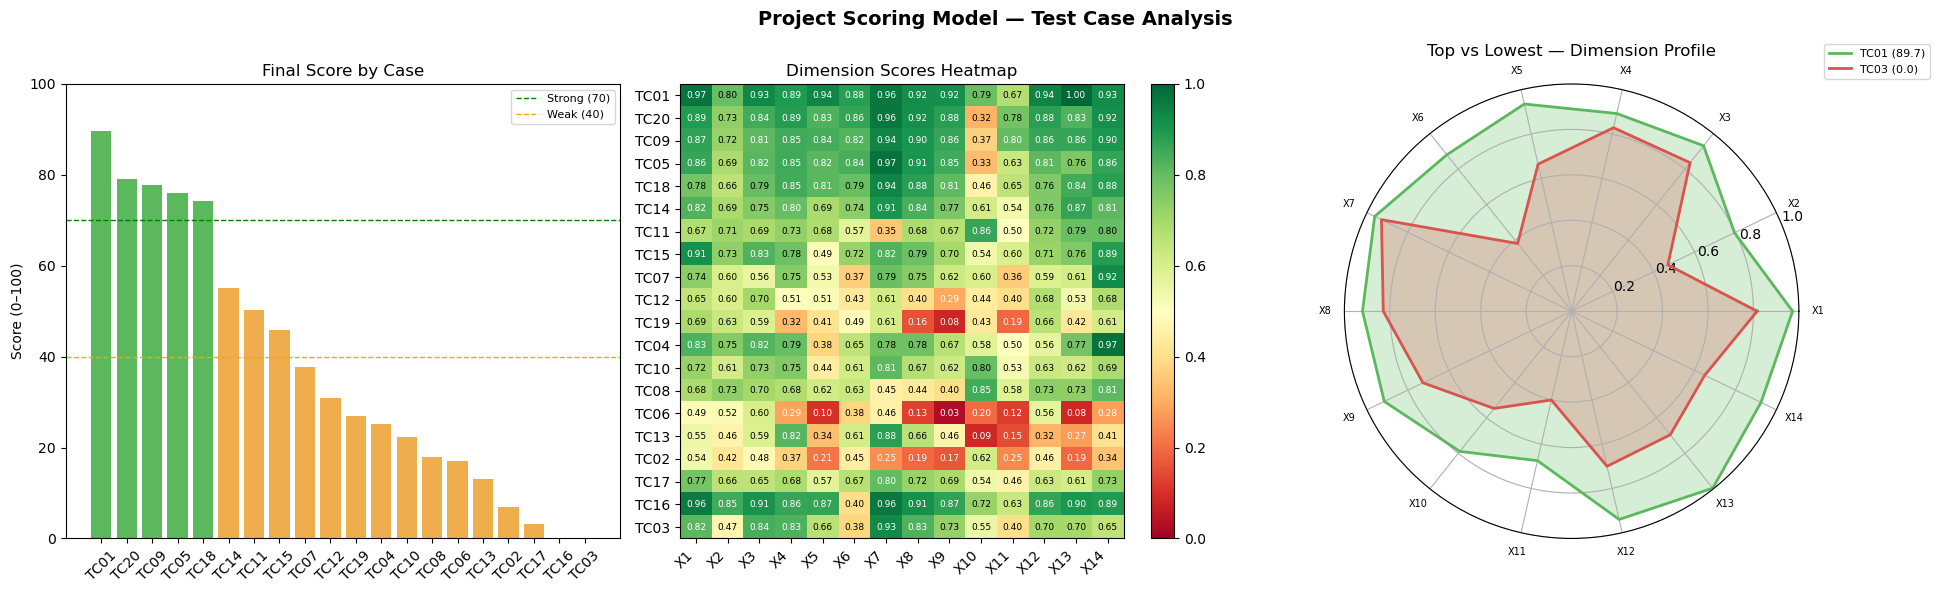

In [38]:
dim_cols = [f"x{i}" for i in range(1, 15)]  # lowercase x to match DataFrame columns

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Project Scoring Model — Test Case Analysis", fontsize=14, fontweight='bold')

colors = ["#d9534f" if s == 0 else "#5cb85c" if s >= 70 else "#f0ad4e"
          for s in df_sorted["Score"]]
axes[0].bar(df_sorted["Case ID"], df_sorted["Score"], color=colors)
axes[0].set_title("Final Score by Case")
axes[0].set_ylabel("Score (0–100)")
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(70, color="green", linestyle="--", linewidth=1, label="Strong (70)")
axes[0].axhline(40, color="orange", linestyle="--", linewidth=1, label="Weak (40)")
axes[0].legend(fontsize=8)

heat_data = df_sorted[dim_cols].values
im = axes[1].imshow(heat_data, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
axes[1].set_xticks(range(len(dim_cols)))
axes[1].set_xticklabels([c.upper() for c in dim_cols], rotation=45, ha='right')
axes[1].set_yticks(range(len(df_sorted)))
axes[1].set_yticklabels(df_sorted["Case ID"])
axes[1].set_title("Dimension Scores Heatmap")
plt.colorbar(im, ax=axes[1])

for i in range(len(df_sorted)):
    for j in range(len(dim_cols)):
        axes[1].text(j, i, f"{heat_data[i, j]:.2f}",
                     ha="center", va="center", fontsize=6.5,
                     color="black" if 0.3 < heat_data[i, j] < 0.8 else "white")

top_vals = df_sorted.iloc[0][dim_cols].values.astype(float)
bot_vals = df_sorted.iloc[-1][dim_cols].values.astype(float)
labels   = [c.upper() for c in dim_cols]
N        = len(dim_cols)
angles   = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

top_vals = np.append(top_vals, top_vals[0])
bot_vals = np.append(bot_vals, bot_vals[0])
angles  += angles[:1]

ax3 = axes[2]
ax3.remove()
ax3 = fig.add_subplot(1, 3, 3, polar=True)
ax3.plot(angles, top_vals, color="#5cb85c", linewidth=2,
         label=f"{df_sorted.iloc[0]['Case ID']} ({df_sorted.iloc[0]['Score']:.1f})")
ax3.fill(angles, top_vals, color="#5cb85c", alpha=0.25)
ax3.plot(angles, bot_vals, color="#d9534f", linewidth=2,
         label=f"{df_sorted.iloc[-1]['Case ID']} ({df_sorted.iloc[-1]['Score']:.1f})")
ax3.fill(angles, bot_vals, color="#d9534f", alpha=0.25)
ax3.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=7)
ax3.set_ylim(0, 1)
ax3.set_title("Top vs Lowest — Dimension Profile", pad=20)
ax3.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)

plt.tight_layout()
plt.show()


In [39]:
df_sorted.to_csv("project_scores_results.csv", index=False)
print("Exported → project_scores_results.csv")

Exported → project_scores_results.csv
